<a href="https://colab.research.google.com/github/anunyathpn/Data-warehouse/blob/main/%E0%B8%AD%E0%B8%99%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2_%E0%B8%97%E0%B8%AD%E0%B8%87%E0%B8%9B%E0%B8%99_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

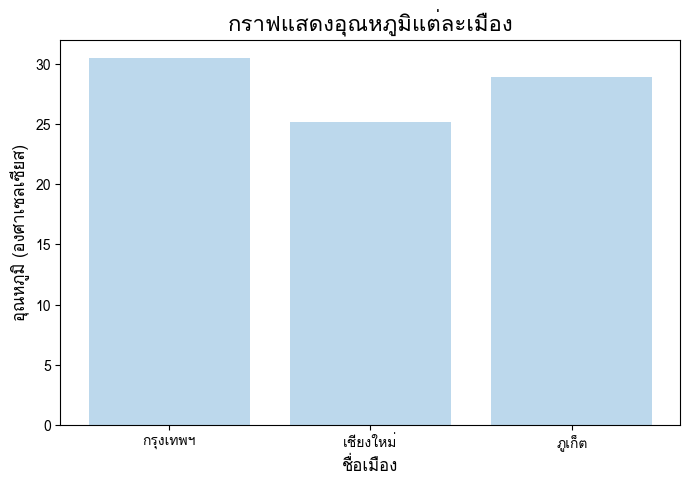

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import timeit
from IPython.display import Markdown, display

# โทนสีพาสเทล Gelato Days
PASTEL_COLORS = ["#FFCBE1", "#D6E5BD", "#F9E1A8", "#BCD8EC", "#DCCCEC", "#FFDAB4"]
PASTEL_CMAP = matplotlib.colors.LinearSegmentedColormap.from_list("gelato_pastel", PASTEL_COLORS)
sns.set_palette(PASTEL_COLORS)

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color=PASTEL_COLORS[3])
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


**ชนิดผลลัพธ์/รูปร่างผลลัพธ์**

* **print(s["a"])** <- ได้ผลลัพธ์เป็น scalar / ไม่มีรูปร่าง

* **print(s.iloc[0])** <- ได้ผลลัพธ์เป็น scalar / ไม่มีรูปร่าง

* **print(s[["a", "c"]])** <- ได้ผลลัพธ์เป็น Pandas Series / รูปร่าง 1 มิติ (N,)

---

**ความหมายค่าที่ได้**

* **print(s["a"])** <- ดึงค่าด้วย label ("a") คืนค่า 10

* **print(s.iloc[0])** <- ดึงค่าด้วยลำดับ ดึงลำดับที่ 0 คืนค่า 10

* **print(s[["a", "c"]])** <- ดึงเฉพาะสมาชิกที่มี label ตรงกับ list ได้เป็นชุดข้อมูลที่มีข้อมูลของ index a (10) และ c (30)

---

**ทางปฏิบัติควรเลือกใช้**

* **print(s["a"])** <- เมื่อต้องการ ดึงข้อมูลค่าเดียว โดยทราบชื่อ Index/Label

* **print(s.iloc[0])** <- เมื่อต้องการ ดึงข้อมูลค่าเดียว โดยระบุตำแหน่งลำดับแถว

* **print(s[["a", "c"]])** <- เมื่อต้องการ ดึงข้อมูลหลายสมาชิก พร้อมกันโดยยังคงโครงสร้าง Series ไว้

In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


**ชนิดผลลัพธ์/รูปร่างผลลัพธ์**

**print(type(df["city"]), df["city"].shape)** <- ได้ผลลัพธ์เป็น Pandas Series / รูปร่าง 1 มิติ (N,)

**print(type(df[["city"]]), df[["city"]].shape)** <- ได้ผลลัพธ์เป็น Pandas DataFrame / รูปร่าง 2 มิติ (N,1)

---

**ความหมายของค่าที่ได้**

**print(type(df["city"]), df["city"].shape)** <- แปลงคอลัมน์ออกมาเป็น array มิติเดียว

**print(type(df[["city"]]), df[["city"]].shape)** <- กรองตารางโดยเลือกมา 1 คอลัมน์ แต่ยังรักษาโครงสร้างตาราง 2D (DataFrame) เอาไว้

---

**ทางปฏิบัติที่ควรเลือกใช้**

**print(type(df["city"]), df["city"].shape)** <- เมื่อต้องการนำคอลัมน์นั้นไปประมวลผลในรูปแบบ Vector 1D

**print(type(df[["city"]]), df[["city"]].shape)** <- เมื่อต้องการผลลัพธ์เป็น DataFrame

In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


**ชนิดผลลัพธ์/รูปร่างผลลัพธ์**

**print(df.loc[0:3].shape)** <- ได้ผลลัพธ์เป็น Pandas DataFrame / รูปร่าง 2 มิติ (4, N)

**print(df.iloc[0:3].shape)** <- ได้ผลลัพธ์เป็น Pandas DataFrame / รูปร่าง 2 มิติ (3, N)

---

**ความหมายของค่าที่ได้**

**print(df.loc[0:3].shape)** <- Slicing ตาม Label ของ Index ซึ่งนับรวมจุดสิ้นสุดด้วย (Inclusive: แถว Index 0, 1, 2, 3)

**print(df.iloc[0:3].shape)** <- Slicing ตามลำดับตำแหน่งจริง (Position Index) ซึ่งไม่นับรวมจุดสิ้นสุด (Exclusive: ลำดับที่ 0, 1, 2)

---

**ทางปฏิบัติที่ควรเลือกใช้**

**print(df.loc[0:3].shape)** <- เมื่อต้องการตัดข้อมูลอ้างอิงตามชื่อ Label ของ Index

**print(df.iloc[0:3].shape)** <- เมื่อต้องการตัดแถวตามลำดับตำแหน่งจริงโดยไม่สนใจชื่อ Label ของ Index

In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


**ชนิดผลลัพธ์/รูปร่างผลลัพธ์**

**print(df.groupby("city")["temperature_c"].count().head(3))** <- ได้ผลลัพธ์เป็น Pandas Series / รูปร่าง 1 มิติ (num_groups,)

**print(df.groupby("city").size().head(3))** <- ได้ผลลัพธ์เป็น Pandas Series / รูปร่าง 1 มิติ (num_groups,)

---

**ความหมายของค่าที่ได้**

**print(df.groupby("city")["temperature_c"].count().head(3))** <- นับจำนวนข้อมูลที่ไม่เป็นค่าว่างในคอลัมน์นั้นๆ ของแต่ละกลุ่ม

**print(df.groupby("city").size().head(3))** <- นับจำนวนบรรทัด/รายการทั้งหมดในแต่ละกลุ่ม

---

**ทางปฏิบัติที่ควรเลือกใช้**

**print(df.groupby("city")["temperature_c"].count().head(3))** <- เมื่อต้องการทราบจำนวนข้อมูลที่มีอยู่อย่างสมบูรณ์ (ไม่นับ Missing Values)

**print(df.groupby("city").size().head(3))** <- เมื่อต้องการทราบจำนวน Record หรือจำนวนแถวทั้งหมดที่เกิดขึ้นในแต่ละกลุ่ม

In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


**ชนิดผลลัพธ์/รูปร่างผลลัพธ์**

**print(df.groupby("city")["temperature_c"].mean().head(3))** <- ได้ผลลัพธ์เป็น Pandas Series / รูปร่าง 1 มิติ (num_groups,)

**print(df.groupby("city")[["temperature_c"]].mean().head(3))** <- ได้ผลลัพธ์เป็น Pandas DataFrame / รูปร่าง 2 มิติ (num_groups, 1)

---

**ความหมายของค่าที่ได้**

**print(df.groupby("city")["temperature_c"].mean().head(3))** <- คำนวณค่าเฉลี่ยของคอลัมน์ แล้วคืนค่าออกมาเป็น array มิติเดียว (Series)

**print(df.groupby("city")[["temperature_c"]].mean().head(3))** <- คำนวณค่าเฉลี่ยของคอลัมน์ แต่ยังรักษาโครงสร้างตาราง 2D (DataFrame) เอาไว้

---

**ทางปฏิบัติที่ควรเลือกใช้**

**print(df.groupby("city")["temperature_c"].mean().head(3))** <- เมื่อต้องการนำค่าเฉลี่ยไปประมวลผลต่อในรูปแบบ Vector 1D

**print(df.groupby("city")[["temperature_c"]].mean().head(3))** <- เมื่อต้องการผลลัพธ์เป็น DataFrame หรือต้องการหาค่าเฉลี่ยของหลายคอลัมน์พร้อมกัน

In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


**ชนิดผลลัพธ์/รูปร่างผลลัพธ์**

**print(a + b)** <- ได้ผลลัพธ์เป็น Pandas Series / รูปร่าง 1 มิติ (3,)

**print(a.to_numpy() + b.to_numpy())** <- ได้ผลลัพธ์เป็น NumPy ndarray / รูปร่าง 1 มิติ (3,)

---

**ความหมายของค่าที่ได้**

**print(a + b)** <- บวกกันด้วย Automatic Index Alignment โดยจับคู่ข้อมูลที่มี Index ชื่อเดียวกันมาบวกกัน

**print(a.to_numpy() + b.to_numpy())** <- ถอด Index ออก แล้วบวกกันตามลำดับตำแหน่งจริง (Positional / Element-wise) โดยไม่สนใจชื่อ Index

---

**ทางปฏิบัติที่ควรเลือกใช้**

**print(a + b)** <- เมื่อต้องการให้การคำนวณถูกต้องตามชื่อ Index และป้องกันความผิดพลาดจากการสลับลำดับแถว

**print(a.to_numpy() + b.to_numpy())** <- เมื่อแน่ใจว่าลำดับข้อมูลตรงกันแล้ว และต้องการคำนวณที่เน้นความเร็วสูง หรือต้องการข้ามการทำงานของ Index Alignment

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [9]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [10]:
# คำตอบข้อ 2.1
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

print("1) 3 เมืองที่มีฝนรวมสูงสุด")
print(rain_by_city.nlargest(3).round(2))

rain_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("\n2) สัดส่วนปริมาณฝนของแต่ละเมือง (%)")
print(rain_pct.sort_values(ascending=False))

n_above = (rain_by_city > rain_by_city.mean()).sum()
print("\n3) จำนวนเมืองที่ฝนรวมสูงกว่าค่าเฉลี่ย =", n_above)


1) 3 เมืองที่มีฝนรวมสูงสุด
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

2) สัดส่วนปริมาณฝนของแต่ละเมือง (%)
city
Singapore       10.43
Bangkok          8.21
Lagos            7.82
Mumbai           5.84
Chiang Mai       5.22
Sao Paulo        5.07
Nairobi          4.74
Tokyo            4.61
Auckland         4.22
Paris            3.99
Sydney           3.97
Toronto          3.81
New York         3.78
Mexico City      3.66
Buenos Aires     3.65
London           3.27
Berlin           3.21
Beijing          3.00
Moscow           2.96
Cape Town        2.87
Lima             2.16
Los Angeles      2.03
Cairo            1.47
Name: rainfall_mm, dtype: float64

3) จำนวนเมืองที่ฝนรวมสูงกว่าค่าเฉลี่ย = 8


In [11]:
print("1) ปริมาณฝนรวมสูงสุด 3 อันดับแรก")
print(rain_by_city.nlargest(3).round(1), "\n")

1) ปริมาณฝนรวมสูงสุด 3 อันดับแรก
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64 



In [12]:
rain_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("2) สัดส่วนปริมาณฝน (%) ของแต่ละเมือง")
print(rain_pct.sort_values(ascending=False))
print("   ผลรวมร้อยละ =", round(rain_pct.sum(), 2), "(ควรใกล้เคียง 100 ต่างกันเล็กน้อยจากการปัดเศษ)\n")

2) สัดส่วนปริมาณฝน (%) ของแต่ละเมือง
city
Singapore       10.43
Bangkok          8.21
Lagos            7.82
Mumbai           5.84
Chiang Mai       5.22
Sao Paulo        5.07
Nairobi          4.74
Tokyo            4.61
Auckland         4.22
Paris            3.99
Sydney           3.97
Toronto          3.81
New York         3.78
Mexico City      3.66
Buenos Aires     3.65
London           3.27
Berlin           3.21
Beijing          3.00
Moscow           2.96
Cape Town        2.87
Lima             2.16
Los Angeles      2.03
Cairo            1.47
Name: rainfall_mm, dtype: float64
   ผลรวมร้อยละ = 99.99 (ควรใกล้เคียง 100 ต่างกันเล็กน้อยจากการปัดเศษ)



In [13]:
mean_rain = rain_by_city.mean()
n_above = (rain_by_city > mean_rain).sum()
print(f"3) ค่าเฉลี่ยปริมาณฝนรวมต่อเมือง = {mean_rain:.2f} มม. -> มี {n_above} เมืองที่สูงกว่าค่าเฉลี่ย (จากทั้งหมด {len(rain_by_city)} เมือง)")

3) ค่าเฉลี่ยปริมาณฝนรวมต่อเมือง = 362.97 มม. -> มี 8 เมืองที่สูงกว่าค่าเฉลี่ย (จากทั้งหมด 23 เมือง)


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [14]:
# คำตอบข้อ 2.2
city_profile = (
    df.groupby("city")
      .agg(country=("country", lambda s: s.mode().iat[0]),
           region=("region", "first"),
           n_records=("record_id", "size"),
           avg_temp=("temperature_c", "mean"),
           total_rain=("rainfall_mm", "sum"))
      .reset_index())
print("หนึ่งแถวต่อหนึ่งเมือง:", city_profile["city"].is_unique, "| รูปร่าง:", city_profile.shape)
city_profile.round(2)

หนึ่งแถวต่อหนึ่งเมือง: True | รูปร่าง: (23, 6)


,city,country,region,n_records,avg_temp,total_rain
0,Auckland,New Zealand,Oceania,90,17.80,351.9
1,Bangkok,Thailand,Asia,91,32.45,685.6
2,Beijing,China,Asia,90,15.60,250.1
3,Berlin,Germany,Europe,90,12.38,268.4
4,Buenos Aires,Argentina,South America,90,19.17,305.1
5,Cairo,Egypt,Africa,91,26.09,123.0
6,Cape Town,South Africa,Africa,90,30.16,239.3
7,Chiang Mai,Thailand,Asia,91,29.68,435.6
8,Lagos,Nigeria,Africa,90,29.49,652.8
9,Lima,Peru,South America,90,21.49,180.3


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [15]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [16]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [17]:
# คำตอบข้อ 3.1
df_opt = pd.read_csv(
    BASE + "world_weather_sample.csv",
    # 1) อ่านเฉพาะ 6 คอลัมน์
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    # 2) แปลง date เป็น datetime
    parse_dates=["date"],
    # 3) 999 และ -999 เป็นค่าว่าง
    na_values=[999, -999],
    # 4) city, region เป็น category
    dtype={"city": "category", "region": "category"},
    # 5) city เป็น index
    index_col="city",)

print(df_opt.dtypes, "\n")
print("ชนิดของ index:", type(df_opt.index).__name__, "| ชื่อ index:", df_opt.index.name, "\n")
df_opt.info()

date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object 

ชนิดของ index: CategoricalIndex | ชื่อ index: city 

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [18]:
# คำตอบข้อ 3.2
from IPython.display import Markdown, display

df_plain = pd.read_csv(BASE + "world_weather_sample.csv")
mem_plain = df_plain.memory_usage(deep=True)
mem_opt = df_opt.reset_index().memory_usage(deep=True)

total_plain, total_opt = mem_plain.sum(), mem_opt.sum()
pct_down = (1 - total_opt / total_plain) * 100
print(f"ก่อน = {total_plain/1024:,.1f} KB | หลัง = {total_opt/1024:,.1f} KB | ลดลง {pct_down:.1f}%\n")

cmp_mem = (pd.DataFrame({"before_bytes": mem_plain, "after_bytes": mem_opt})
             .drop(index="Index", errors="ignore")
             .fillna({"after_bytes": 0}))
cmp_mem["saved_bytes"] = cmp_mem["before_bytes"] - cmp_mem["after_bytes"]
cmp_mem["dtype_before"] = df_plain.dtypes.astype(str)
cmp_mem["dtype_after"] = df_opt.reset_index().dtypes.astype(str)
cmp_mem = cmp_mem.sort_values("saved_bytes", ascending=False)
print(cmp_mem)

kept = cmp_mem[cmp_mem["after_bytes"] > 0]
top_kept, top_all = kept["saved_bytes"].idxmax(), cmp_mem["saved_bytes"].idxmax()
why = {
    "city":   "เป็นข้อความที่ซ้ำกันมาก (มีไม่กี่เมือง) ชนิด category เก็บชื่อเมืองไว้ชุดเดียวแล้วใช้รหัสจำนวนเต็มขนาด 1 ไบต์แทนในทุกแถว",
    "region": "เป็นข้อความที่ซ้ำกันมาก (มี 6 ภูมิภาค) ชนิด category เก็บชื่อไว้ชุดเดียวแล้วใช้รหัสจำนวนเต็มขนาด 1 ไบต์แทนในทุกแถว",
    "date":   "เดิมเป็นสตริงวันที่ซึ่งแต่ละเซลล์เป็นอ็อบเจ็กต์ Python หลายสิบไบต์ แต่ datetime64[ns] ใช้เพียง 8 ไบต์ต่อค่า",}
display(Markdown(
    f"**ผลจากข้อมูล:** หน่วยความจำลดลง **{pct_down:.1f}%** | ในบรรดาคอลัมน์ที่ยังอ่านเข้ามา คอลัมน์ `{top_kept}` ลดมากที่สุด "
    f"({kept.loc[top_kept, 'saved_bytes']/1024:,.1f} KB) เพราะ{why.get(top_kept, 'เปลี่ยนชนิดข้อมูลให้เล็กลง')} "
    f"| เมื่อรวมคอลัมน์ที่ถูกตัดทิ้งด้วย คอลัมน์ที่ช่วยประหยัดมากที่สุดคือ `{top_all}`"))

ก่อน = 558.2 KB | หลัง = 71.3 KB | ลดลง 87.2%

                before_bytes  after_bytes  saved_bytes dtype_before  \
region                117631       2590.0     115041.0       object   
country               114937          0.0     114937.0       object   
city                  116920       3927.0     112993.0       object   
date                  122425      16600.0     105825.0       object   
record_id              16600          0.0      16600.0        int64   
pressure_hpa           16600          0.0      16600.0      float64   
wind_speed_kmh         16600          0.0      16600.0      float64   
humidity_pct           16600      16600.0          0.0      float64   
rainfall_mm            16600      16600.0          0.0      float64   
temperature_c          16600      16600.0          0.0      float64   

                   dtype_after  
region                category  
country                    NaN  
city                  category  
date            datetime64[ns]  
record

**ผลจากข้อมูล:** หน่วยความจำลดลง **87.2%** | ในบรรดาคอลัมน์ที่ยังอ่านเข้ามา คอลัมน์ `region` ลดมากที่สุด (112.3 KB) เพราะเป็นข้อความที่ซ้ำกันมาก (มี 6 ภูมิภาค) ชนิด category เก็บชื่อไว้ชุดเดียวแล้วใช้รหัสจำนวนเต็มขนาด 1 ไบต์แทนในทุกแถว | เมื่อรวมคอลัมน์ที่ถูกตัดทิ้งด้วย คอลัมน์ที่ช่วยประหยัดมากที่สุดคือ `region`

1. **คอลัมน์ชนิด `object` ที่เป็นข้อความ (city, region, date) มีผลมากที่สุด** เพราะ `memory_usage(deep=True)` นับขนาดจริงของอ็อบเจ็กต์ string ใน Python ซึ่งเซลล์หนึ่งใช้หลายสิบไบต์ (ส่วนหัวอ็อบเจ็กต์ประมาณ 49 ไบต์ + ความยาวตัวอักษร + ตัวชี้อีก 8 ไบต์) คูณด้วยจำนวนแถวทั้งหมด
2. **`city` และ `region` เปลี่ยนเป็น `category`** ซึ่งเก็บข้อความที่ไม่ซ้ำเพียงชุดเดียว (23 เมือง, 6 ภูมิภาค) แล้วเก็บรหัสจำนวนเต็มขนาดเล็กในแต่ละแถวแทน จึงได้ผลดีมากกับคอลัมน์ที่มีค่าซ้ำเยอะ (cardinality ต่ำ)
3. **`date` เปลี่ยนเป็น `datetime64[ns]`** ใช้ 8 ไบต์ต่อค่า แทนสตริง 10 ตัวอักษรที่เป็นอ็อบเจ็กต์ Python
4. คอลัมน์ที่ไม่ได้อ่านเข้ามา (`country`, `record_id`, `wind_speed_kmh`, `pressure_hpa`) ก็ช่วยลดขนาดด้วย โดย `country` เป็นข้อความจึงลดได้มากที่สุดในกลุ่มนี้
5. คอลัมน์ตัวเลข (`temperature_c`, `humidity_pct`, `rainfall_mm`) เป็น `float64` เท่าเดิม จึงไม่ได้ประหยัดเพิ่ม

หลักคิดคือ *คอลัมน์ที่มีข้อความซ้ำมากควรเป็น `category` และคอลัมน์วันที่ควรเป็น `datetime`* ยิ่งข้อมูลใหญ่ ผลประหยัดยิ่งมาก

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [19]:
# คำตอบข้อ 3.3
tmin = tmax = None
vmin = vmax = None
sum_by_city = pd.Series(dtype="float64")
cnt_by_city = pd.Series(dtype="float64")
wrong_sum = pd.Series(dtype="float64")
wrong_cnt = pd.Series(dtype="float64")
n_chunks = 0

for chunk in pd.read_csv(BASE + "world_weather_sample.csv", usecols=["city", "temperature_c"],
                         na_values=[999, -999], chunksize=300):
    n_chunks += 1
    t = chunk["temperature_c"]
    tmin = t.min() if tmin is None else np.fmin(tmin, t.min())
    tmax = t.max() if tmax is None else np.fmax(tmax, t.max())
    ok = t[t.between(-60, 60)]
    vmin = ok.min() if vmin is None else np.fmin(vmin, ok.min())
    vmax = ok.max() if vmax is None else np.fmax(vmax, ok.max())

    g = chunk.groupby("city")["temperature_c"]
    sum_by_city = sum_by_city.add(g.sum(), fill_value=0)
    cnt_by_city = cnt_by_city.add(g.count(), fill_value=0)
    m = g.mean()
    wrong_sum = wrong_sum.add(m, fill_value=0)
    wrong_cnt = wrong_cnt.add(m.notna().astype(float), fill_value=0)

print(f"อ่านทั้งหมด {n_chunks} ก้อน")
print(f"1) อุณหภูมิสูงสุด/ต่ำสุดของทั้งไฟล์ = {tmax} / {tmin}")
print(f"   เฉพาะค่าที่เป็นไปได้ (-60..60)      = {vmax} / {vmin}\n")

mean_by_city = sum_by_city / cnt_by_city
wrong_mean = wrong_sum / wrong_cnt
res = pd.DataFrame({"mean_correct": mean_by_city, "mean_of_chunk_means": wrong_mean})
res["error"] = res["mean_of_chunk_means"] - res["mean_correct"]
print("2) อุณหภูมิเฉลี่ยรายเมือง (ถูกต้อง เทียบกับวิธีเฉลี่ยค่าเฉลี่ยรายก้อน)")
print(res.round(4))

อ่านทั้งหมด 7 ก้อน
1) อุณหภูมิสูงสุด/ต่ำสุดของทั้งไฟล์ = 39.2 / -88.0
   เฉพาะค่าที่เป็นไปได้ (-60..60)      = 39.2 / -0.2

2) อุณหภูมิเฉลี่ยรายเมือง (ถูกต้อง เทียบกับวิธีเฉลี่ยค่าเฉลี่ยรายก้อน)
              mean_correct  mean_of_chunk_means   error
city                                                   
Auckland           17.8044              17.8707  0.0663
Bangkok            32.4538              32.5179  0.0641
Beijing            15.5989              15.6101  0.0113
Berlin             12.3831              12.4588  0.0756
Buenos Aires       19.1719              19.2545  0.0826
Cairo              26.0899              26.2692  0.1793
Cape Town          19.1534              19.1511 -0.0024
Chiang Mai         29.6802              29.6774 -0.0028
Lagos              29.4943              29.5875  0.0933
Lima               21.4900              21.4862 -0.0038
London             13.4909              13.4477 -0.0432
Los Angeles        20.6573              20.6228 -0.0345
Mexico City        19

การนำ "ค่าเฉลี่ยของแต่ละก้อน" มาเฉลี่ยกันอีกครั้งให้ผลไม่ถูกต้อง เพราะเป็นการให้น้ำหนักทุกก้อนเท่ากัน ทั้งที่แต่ละก้อนมีจำนวนข้อมูลที่ใช้คำนวณไม่เท่ากัน (ในก้อนหนึ่ง ๆ แต่ละเมืองมีกี่แถวก็ได้ และบางแถวเป็นค่าว่างที่ถูกข้ามไป) ค่าเฉลี่ยจากก้อนที่มีข้อมูลน้อยจึงมีอิทธิพลเกินจริง ผลลัพธ์จึงเพี้ยนจากค่าเฉลี่ยจริง (ตารางด้านบนแสดงค่าคลาดเคลื่อนของแต่ละเมือง)

วิธีที่ถูกต้องคือ **สะสม "ผลรวม" และ "จำนวนข้อมูลที่ไม่ว่าง" ของแต่ละเมืองข้ามทุกก้อน** แล้วหารตอนท้ายครั้งเดียว: ค่าเฉลี่ย = Σ(ผลรวมของทุกก้อน) / Σ(จำนวนของทุกก้อน) ซึ่งเท่ากับค่าเฉลี่ยของข้อมูลทั้งไฟล์พอดี หลักการเดียวกันใช้กับค่าสถิติที่ต้องเก็บ "ตัวสะสม" (sum, count, sum of squares สำหรับความแปรปรวน) ส่วน max/min สะสมได้โดยตรงด้วยการเทียบค่าที่ดีที่สุดเดิมกับค่าของก้อนใหม่

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [21]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [22]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [23]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "example_value": df.bfill().iloc[0],}).sort_values("n_missing", ascending=False)
summary

,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
wind_speed_kmh,float64,41,1.98,278,15.9
pressure_hpa,float64,32,1.54,294,1005.4
temperature_c,float64,20,0.96,331,15.7
record_id,int64,0,0.00,2070,983
date,object,0,0.00,90,2025-03-24
region,object,0,0.00,6,North America
city,object,0,0.00,23,New York
country,object,0,0.00,28,USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [24]:
# คำตอบข้อ 4.2
bad_temp  = (df["temperature_c"] < -60) | (df["temperature_c"] > 60)
bad_humid = (df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)

print("1) แถวที่ temperature_c อยู่นอกช่วง -60 ถึง 60 :", bad_temp.sum(), "แถว | ค่าที่พบ:", sorted(df.loc[bad_temp, "temperature_c"].unique()))
print("2) แถวที่ humidity_pct อยู่นอกช่วง 0 ถึง 100  :", bad_humid.sum(), "แถว | ค่าที่พบ:", sorted(df.loc[bad_humid, "humidity_pct"].unique()))

any_bad = bad_temp | bad_humid
both = (bad_temp & bad_humid).sum()
print("3) แถวที่ผิดปกติอย่างน้อยหนึ่งคอลัมน์ (OR) :", any_bad.sum(), "แถว")
print("   แถวที่ผิดปกติทั้งสองคอลัมน์พร้อมกัน :", both, "แถว")
print("   ถ้าเอา (1)+(2) มาบวกกันตรง ๆ จะได้", bad_temp.sum() + bad_humid.sum(), "แถว (นับซ้ำ", both, "แถว)")

bad_wind = df["wind_speed_kmh"] < 0
print("เสริม: wind_speed_kmh < 0 =", bad_wind.sum(), "แถว | ผิดปกติอย่างน้อยหนึ่งใน 3 คอลัมน์ =", (any_bad | bad_wind).sum(), "แถว")

1) แถวที่ temperature_c อยู่นอกช่วง -60 ถึง 60 : 5 แถว | ค่าที่พบ: [np.float64(-88.0), np.float64(999.0)]
2) แถวที่ humidity_pct อยู่นอกช่วง 0 ถึง 100  : 3 แถว | ค่าที่พบ: [np.float64(150.0)]
3) แถวที่ผิดปกติอย่างน้อยหนึ่งคอลัมน์ (OR) : 8 แถว
   แถวที่ผิดปกติทั้งสองคอลัมน์พร้อมกัน : 0 แถว
   ถ้าเอา (1)+(2) มาบวกกันตรง ๆ จะได้ 8 แถว (นับซ้ำ 0 แถว)
เสริม: wind_speed_kmh < 0 = 2 แถว | ผิดปกติอย่างน้อยหนึ่งใน 3 คอลัมน์ = 10 แถว


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [25]:
# คำตอบข้อ 4.3
raw = df["country"]
clean = raw.str.strip().str.replace(r"\s+", " ", regex=True)
key = clean.str.casefold()
print("จำนวนค่าไม่ซ้ำของ country ก่อนแก้ไข:", raw.nunique())

# 1) ค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกกัน
variants = (pd.DataFrame({"key": key, "country": raw})
              .groupby("key")["country"].agg(lambda s: sorted(s.unique())))
variants = variants[variants.map(len) > 1]
print("\n1) ประเทศที่มีการสะกดมากกว่าหนึ่งแบบ (แสดงด้วย repr เพื่อให้เห็นช่องว่าง):")
for k, v in variants.items():
    print(f"   {k!r:16} -> {v}")

จำนวนค่าไม่ซ้ำของ country ก่อนแก้ไข: 28

1) ประเทศที่มีการสะกดมากกว่าหนึ่งแบบ (แสดงด้วย repr เพื่อให้เห็นช่องว่าง):
   'argentina'      -> ['ARGENTINA', 'Argentina']
   'canada'         -> ['CANADA', 'Canada']
   'germany'        -> ['GERMANY', 'Germany']
   'japan'          -> ['JAPAN', 'Japan']
   'kenya'          -> ['KENYA', 'Kenya']
   'new zealand'    -> ['NEW ZEALAND', 'New Zealand']
   'singapore'      -> ['SINGAPORE', 'Singapore']


In [26]:
# 2) ทดลองใช้ df["country"].str.title()
titled = raw.str.title()
canon = clean.groupby(key).agg(lambda s: s.value_counts().index[0])
damaged = {orig: orig.title() for orig in canon if orig != orig.title()}
print("2) หลังใช้ .str.title() จำนวนค่าไม่ซ้ำ =", titled.nunique())
print("ที่ทำให้เสียหาย:", damaged)

2) หลังใช้ .str.title() จำนวนค่าไม่ซ้ำ = 21
ที่ทำให้เสียหาย: {'UK': 'Uk', 'USA': 'Usa'}


`str.title()` ทำให้ชื่อประเทศที่เป็น **อักษรย่อตัวพิมพ์ใหญ่ทั้งหมด** เสียหาย เช่น `USA` กลายเป็น `Usa` และ `UK` กลายเป็น `Uk` (ชื่อที่เสียหายจริงในข้อมูลดูจากผลลัพธ์ข้อ 2 ด้านบน) เพราะ `title()` แปลงตัวแรกของแต่ละคำเป็นตัวพิมพ์ใหญ่ และ **แปลงตัวอักษรที่เหลือทุกตัวเป็นตัวพิมพ์เล็ก** โดยไม่รู้ว่าคำนั้นเป็นอักษรย่อ นอกจากนี้ `title()` ยัง **ไม่ตัดช่องว่างหัวท้าย** จึงยังมีค่าที่ซ้ำกัน (เช่น `" USA"` กับ `"USA"`) และจำนวนประเทศไม่ได้เท่ากับ 21

In [27]:
# 3) วิธี normalize ที่ถูกต้อง
df["country"] = key.map(canon)
n_country = df["country"].nunique()
print("3) หลัง normalize: จำนวนประเทศ =", n_country, "| ตรงกับเฉลย (21):", n_country == 21)
print("   แต่ละเมืองมีประเทศเดียว:", bool((df.groupby("city")["country"].nunique() == 1).all()))
print("   จำนวนเมือง =", df["city"].nunique())

3) หลัง normalize: จำนวนประเทศ = 21 | ตรงกับเฉลย (21): True
   แต่ละเมืองมีประเทศเดียว: True
   จำนวนเมือง = 23


**วิธี normalize ที่เสนอ**
1. ตัดช่องว่างหัวท้ายและยุบช่องว่างซ้อนด้วย `str.strip()` / `str.replace(r"\s+", " ")`
2. สร้างคีย์เทียบด้วย `str.casefold()` เพื่อจับกลุ่มค่าที่เป็นประเทศเดียวกันโดยไม่สนตัวพิมพ์
3. เลือก **การสะกดที่พบบ่อยที่สุดในแต่ละกลุ่ม** เป็นรูปแบบมาตรฐาน แล้ว `map` กลับ วิธีนี้ไม่ทำลายอักษรย่อและไม่ต้องเขียนรายการประเทศเอง (ไม่ hard-code)

ผลลัพธ์ได้ 21 ประเทศ ตรงกับเฉลยของโจทย์

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [28]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [29]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [30]:
# คำตอบข้อ 5.1
# 1) แถวตำแหน่งเลขคู่ 10 แถวแรก (ตำแหน่ง 0,2,4,...,18 นับจาก 0) เฉพาะสามคอลัมน์สุดท้าย
part1 = df.iloc[0:20:2, -3:]
print("1)", part1.shape)
print(part1, "\n")

1) (10, 3)
    rainfall_mm  wind_speed_kmh  pressure_hpa
0           6.3            15.9        1005.4
2           1.2             8.6        1013.5
4           0.0            16.6        1015.1
6           2.7            14.6        1018.0
8           1.6             9.8        1007.7
10          0.0            15.6        1010.1
12          0.0            13.6        1015.8
14          2.2            24.6        1000.5
16          8.3             9.3        1019.4
18          8.9            23.3        1020.6 



In [31]:
# 2) ห้าแถวสุดท้าย เรียงจากแถวล่างสุดขึ้นไป (สไลซ์ด้วยก้าวติดลบ)
part2 = df.iloc[:-6:-1]
print("2) ดัชนีแถวที่ได้:", part2.index.tolist())
print(part2, "\n")

2) ดัชนีแถวที่ได้: [2074, 2073, 2072, 2071, 2070]
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  
2074           11.1          65.8          6.3            20.4        1015.7  
2073            NaN          65.0          9.1             6.9        1007.8  
2072           21.7          51.0          9.5            27.2        1013.9  
2071           20.6          65.8          3.7            13.3        1015.6  
2070           17.8          63.3          7.4            10.5        1001.2   



In [32]:
mid = len(df) // 2
part3 = df.iloc[mid, -1]
print(f"3) แถวกึ่งกลาง = ตำแหน่ง {mid} (จาก {len(df)} แถว), คอลัมน์สุดท้าย -> {part3}")

3) แถวกึ่งกลาง = ตำแหน่ง 1037 (จาก 2075 แถว), คอลัมน์สุดท้าย -> 1020.9


### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [33]:
# คำตอบข้อ 5.2
multi = df.set_index(["region", "city"]).sort_index()

# 1) ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
q1 = multi.loc["Asia", ["date", "temperature_c"]]
print("1)", q1.shape); print(q1.head(3), "\n")

1) (542, 2)
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9 



In [34]:
# 2) เมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
q2 = multi.loc[pd.IndexSlice[:, ["Tokyo", "Bangkok"]], :]
print("2)", q2.shape, "| เมืองที่ได้:", sorted(q2.index.get_level_values("city").unique()), "\n")

2) (181, 8) | เมืองที่ได้: ['Bangkok', 'Tokyo'] 



In [35]:
# 3) ทุกภูมิภาค เฉพาะเมืองที่ชื่อขึ้นต้นด้วย B (ใช้ boolean mask จากระดับ city)
q3 = multi.loc[multi.index.get_level_values("city").str.startswith("B")]
print("3)", q3.shape, "| เมืองที่ได้:", sorted(q3.index.get_level_values("city").unique()), "\n")

3) (361, 8) | เมืองที่ได้: ['Bangkok', 'Beijing', 'Berlin', 'Buenos Aires'] 



**เหตุใดควร `.sort_index()` ก่อนใช้ MultiIndex**

1. การเลือกช่วงข้อมูล (slice) บน index หลายระดับต้องการให้ index **เรียงลำดับแบบ lexsorted** ถ้ายังไม่เรียง pandas จะแจ้ง `UnsortedIndexError` (หรือ `PerformanceWarning`) เพราะไม่สามารถรู้ว่าช่วง `"Africa":"Asia"` เริ่มและจบตรงไหน
2. เมื่อเรียงแล้ว pandas ใช้การค้นหาแบบ binary search ได้ ทำให้ `.loc` เร็วกว่าการไล่ดูทุกแถวมาก และแถวของกลุ่มเดียวกันอยู่ติดกัน
3. ผลลัพธ์ที่ได้มีลำดับที่คาดเดาได้ ไม่ขึ้นกับลำดับแถวเดิมในไฟล์ จึงทำซ้ำได้เสมอ

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [36]:
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0

/tmp/ipykernel_3791/427233649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0


In [37]:
# คำตอบข้อ 5.3
bkk_before = df.loc[df["city"] == "Bangkok", "temperature_c"].mean()

backup = df["temperature_c"].copy()
df.loc[df["city"] == "Bangkok", "temperature_c"] = 0
print("รูปแบบที่ 1 (แก้ df จริง) ค่าเฉลี่ย Bangkok หลังแก้ =", df.loc[df["city"] == "Bangkok", "temperature_c"].mean())
df["temperature_c"] = backup
print("คืนค่าเดิมแล้ว:", np.isclose(df.loc[df["city"] == "Bangkok", "temperature_c"].mean(), bkk_before))

รูปแบบที่ 1 (แก้ df จริง) ค่าเฉลี่ย Bangkok หลังแก้ = 0.0
คืนค่าเดิมแล้ว: True


In [38]:
bkk = df[df["city"] == "Bangkok"].copy()
bkk["temperature_c"] = 0
df_new = df.assign(temperature_c=df["temperature_c"].mask(df["city"] == "Bangkok", 0))
print("รูปแบบที่ 2 (สำเนา) df เดิมยังเท่าเดิม:", np.isclose(df.loc[df["city"] == "Bangkok", "temperature_c"].mean(), bkk_before),
      "| df_new เฉลี่ย Bangkok =", df_new.loc[df_new["city"] == "Bangkok", "temperature_c"].mean())

รูปแบบที่ 2 (สำเนา) df เดิมยังเท่าเดิม: True | df_new เฉลี่ย Bangkok = 0.0


**สรุปแนวปฏิบัติของตนเอง**

- เมื่อกรองด้วย `df[เงื่อนไข]` แล้วนำไปแก้ค่าต่อ ผลที่ได้เป็นสำเนา/มุมมองชั่วคราว การแก้จะไม่ไปถึง `df` เดิม (และ pandas รุ่นเก่าจะแจ้ง `SettingWithCopyWarning`) ห้ามเขียน `df[เงื่อนไข]["col"] = ...` (chained assignment)
- ถ้าต้องการ **แก้ df จริง** ให้ระบุแถวและคอลัมน์ในคำสั่งเดียวด้วย `df.loc[เงื่อนไข, "col"] = ค่า` ถ้าต้องการ **ทำงานกับสำเนา** ให้เขียน `.copy()` อย่างชัดเจน หรือใช้ `assign` / `where` / `mask` ที่คืน DataFrame ใหม่
- ก่อนแก้ข้อมูลหลักให้สำรองไว้หรือทดลองบนสำเนาเสมอ แล้วตรวจผลด้วยการเทียบค่าก่อน/หลัง

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [39]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [40]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [41]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [42]:
# คำตอบข้อ 6.1
# 1) ภูมิภาคเอเชีย ฝน > 5 มม. และ ลม > 20 กม./ชม.
c1 = df[(df["region"] == "Asia") & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]

# 2) ไม่ใช่เมือง Bangkok, Tokyo, London และความชื้นอยู่ระหว่าง 40 ถึง 60
c2 = df[~df["city"].isin(["Bangkok", "Tokyo", "London"]) & df["humidity_pct"].between(40, 60)]

# 3) แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
c3 = df[df.isna().sum(axis=1) >= 2]

# 4) ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ (regex: \b คือขอบเขตของคำ, (?:...) เป็นกลุ่มที่ไม่จับค่า)
c4 = df[df["city"].str.contains(r"\b(?:New|San)\b", regex=True)]

print("1)", len(c1), "แถว"); print("2)", len(c2), "แถว"); print("3)", len(c3), "แถว")
print("4)", len(c4), "แถว | เมืองที่ได้:", c4["city"].unique().tolist())
c1.head(3)

1) 54 แถว
2) 470 แถว
3) 8 แถว
4) 90 แถว | เมืองที่ได้: ['New York']


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
38,517,2025-03-08,Mumbai,India,Asia,32.6,73.1,5.8,22.3,1019.6
49,525,2025-03-16,Mumbai,India,Asia,33.6,76.3,6.3,23.5,1015.5
178,51,2025-02-20,Bangkok,Thailand,Asia,29.9,82.3,16.5,21.2,1003.9


In [43]:
c2.head(3)

,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1
8,1382,2025-02-01,Buenos Aires,Argentina,South America,20.8,58.7,1.6,9.8,1007.7


In [44]:
c3.head(3)

,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
43,1582,2025-02-21,Cairo,Egypt,Africa,NaN,45.7,NaN,19.6,1017.7
420,1943,2025-02-22,Sydney,Australia,Oceania,18.5,70.4,0.0,NaN,NaN
438,1684,2025-03-05,Lagos,Nigeria,Africa,31.3,NaN,7.4,NaN,1009.9


In [45]:
c4.head(3)

,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
47,979,2025-03-20,New York,USA,North America,14.9,52.2,0.7,14.3,1006.6
63,917,2025-01-17,New York,USA,North America,14.7,54.1,3.0,19.7,1011.9


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [46]:
# คำตอบข้อ 6.2
df["temperature_valid"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))

p99 = df["rainfall_mm"].quantile(0.99)
df["rainfall_capped_p99"] = df["rainfall_mm"].mask(df["rainfall_mm"] > p99, p99)

print("จำนวนแถวไม่เปลี่ยน:", len(df))
print("อุณหภูมิ: ค่าว่างก่อน =", df["temperature_c"].isna().sum(), "-> หลัง =", df["temperature_valid"].isna().sum(),
      "(ค่าผิดปกติที่ถูกแทนด้วยค่าว่าง =", df["temperature_valid"].isna().sum() - df["temperature_c"].isna().sum(), "ค่า)")
print(f"ฝน: p99 = {p99:.2f} มม. | ค่าสูงสุดก่อน = {df['rainfall_mm'].max()} -> หลัง = {df['rainfall_capped_p99'].max()}",
      "| จำนวนค่าที่ถูกจำกัด =", (df["rainfall_mm"] > p99).sum())
df[["temperature_c", "temperature_valid", "rainfall_mm", "rainfall_capped_p99"]].describe().round(2)

จำนวนแถวไม่เปลี่ยน: 2075
อุณหภูมิ: ค่าว่างก่อน = 20 -> หลัง = 25 (ค่าผิดปกติที่ถูกแทนด้วยค่าว่าง = 5 ค่า)
ฝน: p99 = 14.69 มม. | ค่าสูงสุดก่อน = 17.6 -> หลัง = 14.687999999999988 | จำนวนค่าที่ถูกจำกัด = 21


,temperature_c,temperature_valid,rainfall_mm,rainfall_capped_p99
count,2055.00,2050.00,2013.00,2013.00
mean,21.84,20.51,4.15,4.14
std,38.22,7.24,3.85,3.82
min,-88.00,-0.20,0.00,0.00
25%,15.40,15.42,0.30,0.30
50%,20.00,20.00,3.50,3.50
75%,25.70,25.68,6.60,6.60
max,999.00,39.20,17.60,14.69


**`where`/`mask` ต่างจากการลบแถวทิ้งอย่างไร**

- **จำนวนแถวและ index คงเดิม** `where`/`mask` เปลี่ยนเฉพาะ "ค่า" ในเซลล์ที่มีปัญหา แต่แถวนั้นยังอยู่ จึงไม่เสียค่าที่ดีของคอลัมน์อื่นในแถวเดียวกัน (ความชื้น ฝน ลม ฯลฯ) ส่วนการลบแถวจะทิ้งข้อมูลดีทั้งแถวไปด้วยเพราะผิดปกติเพียงคอลัมน์เดียว
- **โครงสร้างข้อมูลยังสมบูรณ์** จำนวนวันต่อเมืองยังครบ 90 วัน ทำให้ `resample`, `rolling`, `ffill` รายเมือง และการนับจำนวนวัน ยังทำงานถูกต้อง การลบแถวทำให้เกิดช่องว่างในลำดับเวลาและทำให้แต่ละเมืองมีจำนวนแถวไม่เท่ากัน
- **ค่าว่างถูกจัดการต่อได้ในขั้นถัดไป** ฟังก์ชันสถิติ (`mean`, `std`, `corr`) ข้ามค่าว่างให้อัตโนมัติ หรือจะเลือกเติมค่า (ข้อ 8) ทีหลังได้ โดยยังรู้ว่าตำแหน่งใดเคยผิดปกติ ขณะที่การลบแถวแล้วย้อนกลับไม่ได้
- **ลดอคติจากการสูญเสียข้อมูลไม่เท่ากัน** ถ้าลบแถว เมืองที่มีค่าผิดปกติมากจะเสียข้อมูลมากกว่าเมืองอื่น ผลสรุประหว่างเมืองจึงไม่เป็นธรรม
- `mask` แบบจำกัดค่าสูงสุดที่ P99 (winsorizing) ยังคงข้อมูลไว้แต่ลดอิทธิพลของค่าสุดโต่งต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน ข้อควรระวังคือการจำกัดค่าเปลี่ยนการกระจายของข้อมูล จึงควรระบุไว้ในรายงาน

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [47]:
# คำตอบข้อ 6.3
tmp = df.assign(deviation=df["temperature_c"] - df.groupby("city")["temperature_c"].transform("mean"))
tmp["abs_dev"] = tmp["deviation"].abs()

idx = tmp.groupby("city")["abs_dev"].idxmax()
farthest = (tmp.loc[idx, ["city", "date", "temperature_c", "deviation"]]
               .reset_index(drop=True))
print("หนึ่งแถวต่อหนึ่งเมือง:", farthest["city"].is_unique, "|", farthest.shape)
farthest.round(2)

หนึ่งแถวต่อหนึ่งเมือง: True | (23, 4)


,city,date,temperature_c,deviation
0,Auckland,2025-02-27,25.6,7.80
1,Bangkok,2025-03-26,39.1,6.65
2,Beijing,2025-03-06,22.6,7.00
3,Berlin,2025-03-26,19.4,7.02
4,Buenos Aires,2025-01-19,-88.0,-107.17
5,Cairo,2025-03-31,33.6,7.51
6,Cape Town,2025-02-10,999.0,968.84
7,Chiang Mai,2025-03-28,37.3,7.62
8,Lagos,2025-01-01,21.1,-8.39
9,Lima,2025-01-22,12.9,-8.59


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [48]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [49]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [50]:
# คำตอบข้อ 7.1
df7 = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week.astype(int),
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5,)
df7[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head()

,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [51]:
# คำตอบข้อ 7.2
# 1) ช่วงเวลาที่ข้อมูลครอบคลุม และวันที่ไม่มีข้อมูลเลย
d0, d1 = df["date"].min(), df["date"].max()
n_days = (d1 - d0).days + 1
full_range = pd.date_range(d0, d1, freq="D")
missing_days = full_range.difference(pd.DatetimeIndex(df["date"].unique()))
print(f"1) ข้อมูลครอบคลุม {d0.date()} ถึง {d1.date()} = {n_days} วัน | วันที่ไม่มีข้อมูลเลย = {len(missing_days)} วัน",
      "(ข้อมูลต่อเนื่องครบทุกวัน)" if len(missing_days) == 0 else missing_days.date.tolist())

1) ข้อมูลครอบคลุม 2025-01-01 ถึง 2025-03-31 = 90 วัน | วันที่ไม่มีข้อมูลเลย = 0 วัน (ข้อมูลต่อเนื่องครบทุกวัน)


In [52]:
# 2) อุณหภูมิเฉลี่ยวันหยุดสุดสัปดาห์เทียบกับวันธรรมดา จำแนกตามภูมิภาค
wk = (df7.groupby(["region", "is_weekend"])["temperature_valid"].mean()
         .unstack().rename(columns={False: "weekday", True: "weekend"}))
wk["weekend_minus_weekday"] = wk["weekend"] - wk["weekday"]
print("2) อุณหภูมิเฉลี่ย (องศาเซลเซียส)")
print(wk.round(2))

2) อุณหภูมิเฉลี่ย (องศาเซลเซียส)
is_weekend     weekday  weekend  weekend_minus_weekday
region                                                
Africa           24.08    23.88                  -0.19
Asia             26.25    26.53                   0.28
Europe           11.93    11.95                   0.02
North America    16.72    16.84                   0.13
Oceania          18.94    19.40                   0.46
South America    21.70    21.26                  -0.44


In [53]:
# 3) เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
monthly_rain = df7.groupby(["city", "year_month"], as_index=False)["rainfall_mm"].sum()
wettest = monthly_rain.loc[monthly_rain.groupby("city")["rainfall_mm"].idxmax()].reset_index(drop=True)
print("3) เดือนที่ฝนรวมสูงสุดของแต่ละเมือง")
print(wettest.round(1).to_string(index=False))

3) เดือนที่ฝนรวมสูงสุดของแต่ละเมือง
        city year_month  rainfall_mm
    Auckland    2025-03        150.0
     Bangkok    2025-02        243.9
     Beijing    2025-02         87.4
      Berlin    2025-03        100.1
Buenos Aires    2025-02        121.2
       Cairo    2025-02         48.0
   Cape Town    2025-01         98.3
  Chiang Mai    2025-03        188.0
       Lagos    2025-03        233.0
        Lima    2025-01         88.0
      London    2025-01        117.2
 Los Angeles    2025-01         78.6
 Mexico City    2025-01        124.2
      Moscow    2025-02         93.6
      Mumbai    2025-02        171.9
     Nairobi    2025-01        178.2
    New York    2025-01        113.6
       Paris    2025-03        122.5
   Sao Paulo    2025-03        155.2
   Singapore    2025-01        321.4
      Sydney    2025-01        134.2
       Tokyo    2025-01        145.2
     Toronto    2025-02        109.2


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [54]:
# คำตอบข้อ 7.3
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
weekly = bkk.resample("7D").agg(avg_temp=("temperature_valid", "mean"),
                                total_rain=("rainfall_mm", "sum"))
print(weekly.round(2))

print("\ngroupby(เดือน) :")
print(bkk["temperature_valid"].groupby(bkk.index.month).mean().round(2))

            avg_temp  total_rain
date                            
2025-01-01     30.36        65.7
2025-01-08     31.09        47.6
2025-01-15     30.39        58.7
2025-01-22     32.29        50.0
2025-01-29     31.76        55.4
2025-02-05     33.03        65.1
2025-02-12     34.21        60.2
2025-02-19     32.30        42.5
2025-02-26     32.34        61.7
2025-03-05     32.99        49.1
2025-03-12     33.04        56.4
2025-03-19     33.16        41.9
2025-03-26     35.40        31.3

groupby(เดือน) :
date
1    31.22
2    32.68
3    33.45
Name: temperature_valid, dtype: float64


| | `resample()` | `groupby(dt.month)` |
|---|---|---|
| หลักการ | แบ่งแกนเวลาเป็น **ช่วงต่อเนื่องที่มีความยาวคงที่** (7 วัน, 3 ชั่วโมง, รายไตรมาส ฯลฯ) | จัดกลุ่มตาม **ค่าของแอตทริบิวต์** (เลขเดือน) |
| ช่วงเวลาที่ไม่มีข้อมูล | สร้างช่วงนั้นให้ด้วย (ผลรวม = 0, ค่าเฉลี่ย = NaN) ผลลัพธ์จึงเป็นอนุกรมเวลาต่อเนื่อง | ไม่มีกลุ่มนั้นในผลลัพธ์ |
| ข้ามปี | แยกมกราคม 2025 กับมกราคม 2026 ออกจากกัน | **รวมมกราคมของทุกปีเข้าด้วยกัน** |
| ต้องการ | index เป็น datetime | ไม่ต้อง |

กรณีที่ **จำเป็นต้องใช้ `resample()` เท่านั้น**
1. ช่วงที่ไม่ตรงกับหน่วยในปฏิทิน เช่น ทุก 7 วัน, 10 วัน, 15 นาที, 3 ชั่วโมง ซึ่งไม่มีแอตทริบิวต์ `.dt.xxx` ให้จัดกลุ่ม
2. ต้องการผลลัพธ์ที่ **ช่วงเวลาครบต่อเนื่อง** แม้บางช่วงไม่มีข้อมูล (เพื่อ plot หรือเติมค่าต่อ)
3. การ **upsample** (เพิ่มความถี่ เช่น รายวันเป็นรายชั่วโมง แล้ว `ffill`/`interpolate`) และการเลือกจุดอ้างอิงของช่วงด้วย `origin`/`closed`/`label`

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [55]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [56]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [57]:
# คำตอบข้อ 8.1
# 1) คอลัมน์ที่มีค่าว่างมากที่สุด
miss_pct = df.isna().mean().mul(100)
col_max = miss_pct.idxmax()
print(f"1) คอลัมน์ที่มีค่าว่างมากที่สุดคือ {col_max}: {df[col_max].isna().sum()} แถว = {miss_pct.max():.2f}% ของทั้งหมด\n")

1) คอลัมน์ที่มีค่าว่างมากที่สุดคือ humidity_pct: 82 แถว = 3.95% ของทั้งหมด



In [58]:
# 2) สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง
temp_miss = (df["temperature_c"].isna().groupby(df["city"])
               .agg(n_missing="sum", n_rows="size", pct_missing="mean"))
temp_miss["pct_missing"] = (temp_miss["pct_missing"] * 100).round(2)
temp_miss = temp_miss.sort_values("pct_missing", ascending=False)
print("2) สัดส่วนค่าว่างของ temperature_c รายเมือง (เรียงจากมากไปน้อย)")
print(temp_miss)
print(f"   ต่ำสุด {temp_miss['pct_missing'].min()}% | สูงสุด {temp_miss['pct_missing'].max()}% | "
      f"เมืองที่ไม่มีค่าว่างเลย {(temp_miss['n_missing'] == 0).sum()} เมือง ->",
      "กระจายไม่เท่ากันทุกเมือง" if temp_miss["pct_missing"].nunique() > 1 else "เท่ากันทุกเมือง", "\n")

2) สัดส่วนค่าว่างของ temperature_c รายเมือง (เรียงจากมากไปน้อย)
              n_missing  n_rows  pct_missing
city                                        
Lagos                 3      90         3.33
London                2      90         2.22
Toronto               2      90         2.22
Tokyo                 2      90         2.22
Cairo                 2      91         2.20
Berlin                1      90         1.11
Beijing               1      90         1.11
Paris                 1      90         1.11
Sao Paulo             1      90         1.11
Cape Town             1      90         1.11
Buenos Aires          1      90         1.11
Los Angeles           1      90         1.11
Moscow                1      91         1.10
Nairobi               1      91         1.10
Bangkok               0      91         0.00
Auckland              0      90         0.00
Mexico City           0      90         0.00
Chiang Mai            0      91         0.00
Lima                  0      90     

In [59]:
# 3) ถ้า dropna() ทุกแถวที่มีค่าว่าง จะเหลือข้อมูลเท่าใด และเมืองใดสูญเสียมากที่สุด
base_cols = ["record_id", "date", "city", "country", "region", "temperature_c", "humidity_pct",
             "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
complete = df[base_cols].dropna()
print(f"3) หลัง dropna() เหลือ {len(complete)} จาก {len(df)} แถว = {len(complete)/len(df)*100:.2f}% ของข้อมูลเดิม")

rows_city = df.groupby("city").size()
lost = rows_city - complete.groupby("city").size().reindex(rows_city.index, fill_value=0)
loss = pd.DataFrame({"rows": rows_city, "lost_rows": lost, "pct_lost": (lost / rows_city * 100).round(2)})
print("   เมืองที่สูญเสียมากที่สุด 5 อันดับ")
print(loss.sort_values("lost_rows", ascending=False).head(5))
print("   สูญเสียมากที่สุดโดยจำนวนแถว:", loss["lost_rows"].idxmax(), "| โดยสัดส่วน:", loss["pct_lost"].idxmax())

3) หลัง dropna() เหลือ 1846 จาก 2075 แถว = 88.96% ของข้อมูลเดิม
   เมืองที่สูญเสียมากที่สุด 5 อันดับ
          rows  lost_rows  pct_lost
city                               
Auckland    90         14     15.56
Bangkok     91         13     14.29
London      90         13     14.44
Lagos       90         12     13.33
Tokyo       90         12     13.33
   สูญเสียมากที่สุดโดยจำนวนแถว: Auckland | โดยสัดส่วน: Auckland


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [60]:
# คำตอบข้อ 8.2
d = df.sort_values(["city", "date"]).copy()
d["t_orig"] = d["temperature_c"].where(d["temperature_c"].between(-60, 60))

# 1) ค่าเฉลี่ยรวมทั้งตาราง
d["fill_global"] = d["t_orig"].fillna(d["t_orig"].mean())
# 2) ค่าเฉลี่ยของเมืองตนเอง
d["fill_city"]   = d["t_orig"].fillna(d.groupby("city")["t_orig"].transform("mean"))
# 3) ค่าของวันก่อนหน้าในเมืองเดียวกัน
d["fill_ffill"]  = d.groupby("city")["t_orig"].ffill()

methods = {"original (ก่อนเติม)": "t_orig", "global_mean": "fill_global", "city_mean": "fill_city", "ffill": "fill_ffill"}
def city_stats(col):
    g = d.groupby("city")[col]
    return pd.DataFrame({"mean": g.mean(), "std": g.std()})
cmp_fill = pd.concat({name: city_stats(col) for name, col in methods.items()}, axis=1)
print("ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายเมือง ตามวิธีเติมค่า")
print(cmp_fill.round(2))

orig = cmp_fill["original (ก่อนเติม)"]
impact = pd.DataFrame({
    name: {"เฉลี่ยของ |เปลี่ยนแปลงค่าเฉลี่ยรายเมือง|": (cmp_fill[name]["mean"] - orig["mean"]).abs().mean(),
           "เฉลี่ยของ std ใหม่ / std เดิม": (cmp_fill[name]["std"] / orig["std"]).mean(),
           "ค่าว่างที่เหลือ": d[col].isna().sum()}
    for name, col in methods.items() if name != "original (ก่อนเติม)"}).T
print("\nสรุปผลกระทบเทียบกับก่อนเติม (ภาพรวมทุกเมือง)")
print(impact.round(4))

lowest_std = impact["เฉลี่ยของ std ใหม่ / std เดิม"].idxmin()
worst_mean = impact["เฉลี่ยของ |เปลี่ยนแปลงค่าเฉลี่ยรายเมือง|"].idxmax()
display(Markdown(f"**ผลจากข้อมูล:** วิธีที่ทำให้ค่าเฉลี่ยรายเมืองเปลี่ยนมากที่สุดคือ `{worst_mean}` | "
                 f"วิธีที่ทำให้ส่วนเบี่ยงเบนมาตรฐานลดลงมากที่สุดคือ `{lowest_std}`"))

ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายเมือง ตามวิธีเติมค่า
             original (ก่อนเติม)       global_mean       city_mean        \
                            mean   std        mean   std      mean   std   
city                                                                       
Auckland                   17.80  2.80       17.80  2.80     17.80  2.80   
Bangkok                    32.45  2.48       32.45  2.48     32.45  2.48   
Beijing                    15.60  2.87       15.65  2.91     15.60  2.86   
Berlin                     12.38  2.60       12.47  2.72     12.38  2.58   
Buenos Aires               20.39  2.78       20.39  2.75     20.39  2.75   
Cairo                      26.09  2.73       25.97  2.83     26.09  2.70   
Cape Town                  19.15  2.74       19.18  2.72     19.15  2.71   
Chiang Mai                 29.68  2.86       29.68  2.86     29.68  2.86   
Lagos                      29.49  2.84       29.19  3.23     29.49  2.79   
Lima                 

**ผลจากข้อมูล:** วิธีที่ทำให้ค่าเฉลี่ยรายเมืองเปลี่ยนมากที่สุดคือ `global_mean` | วิธีที่ทำให้ส่วนเบี่ยงเบนมาตรฐานลดลงมากที่สุดคือ `city_mean`

- **วิธีที่เหมาะสมที่สุดกับข้อมูลชุดนี้คือเติมด้วยค่าของวันก่อนหน้าในเมืองเดียวกัน (`ffill` รายเมือง)** เพราะอุณหภูมิรายวันของเมืองหนึ่ง ๆ มี *autocorrelation* สูง (วันนี้ใกล้เคียงเมื่อวาน) และมีแนวโน้มตามฤดูกาลช่วงม.ค.-มี.ค. การเติมด้วยค่าใกล้เคียงในเวลาจึงรักษาค่าเฉลี่ยและความผันผวนของเมืองไว้ได้ใกล้เคียงเดิมที่สุด (ข้อควรระวังคือถ้าวันแรกของเมืองเป็นค่าว่างจะยังเหลือค่าว่าง และถ้าขาดหายติดกันหลายวันจะได้ค่าซ้ำ ๆ)
- **ค่าเฉลี่ยรวมทั้งตาราง** ใช้ไม่เหมาะ เพราะเมืองหนาว (เช่น ยุโรป) และเมืองร้อน (เช่น เอเชียตะวันออกเฉียงใต้) มีระดับอุณหภูมิต่างกันมาก การเติมด้วยค่ากลางของทุกเมืองทำให้ค่าเฉลี่ยของแต่ละเมืองเพี้ยนไปหาค่ารวม และเป็นการใส่ค่าที่เป็นไปไม่ได้สำหรับเมืองนั้น
- **ค่าเฉลี่ยของเมืองตนเอง** ทำให้ค่าเฉลี่ยของเมืองเกือบไม่เปลี่ยน แต่เป็นการเติมด้วย **ค่าคงที่ตัวเดียว** ซ้ำ ๆ ที่ศูนย์กลางของการกระจาย จึง **ทำให้ความแปรปรวน (ส่วนเบี่ยงเบนมาตรฐาน) ลดลงอย่างผิดธรรมชาติ** ยิ่งมีค่าว่างมากยิ่งลดมาก และยังไม่สะท้อนแนวโน้มตามเวลา

สรุป: การเติมด้วยค่าคงที่ (เฉลี่ยรวม/เฉลี่ยเมือง) บิดเบือนการกระจายของข้อมูล ส่วนตัวเลขที่เปลี่ยนจริงของแต่ละวิธีดูได้จากตารางผลกระทบด้านบน

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [61]:
# คำตอบข้อ 8.3
keys = ["city", "date"]

# 1) จำนวนคู่ (city, date) ที่ซ้ำกัน
dup_mask = df.duplicated(subset=keys, keep=False)
n_extra = df.duplicated(subset=keys).sum()
n_pairs = df.loc[dup_mask, keys].drop_duplicates().shape[0]
print(f"1) คู่ (city, date) ที่ซ้ำกัน = {n_pairs} คู่ (มีแถวส่วนเกิน {n_extra} แถว)")

1) คู่ (city, date) ที่ซ้ำกัน = 5 คู่ (มีแถวส่วนเกิน 5 แถว)


In [62]:
dups = df[dup_mask].sort_values(keys)
value_cols = [c for c in df.columns if c not in keys]
n_all_dup = df.duplicated().sum()

print("2) แถวที่ซ้ำ (เรียงตามคีย์)")
print(dups[["record_id", "city", "date", "temperature_c", "humidity_pct", "rainfall_mm"]].to_string(index=False))
print(f"   ซ้ำเฉพาะคีย์ = {n_extra} แถว | ซ้ำทุกคอลัมน์ = {n_all_dup} แถว")

if n_extra == 0:
    print("   จำนวนค่าที่ต่างกันสูงสุดภายในกลุ่มซ้ำ (ทุกคอลัมน์): 0")
    print("   สรุป: ไม่มีข้อมูลคู่ (city, date) ที่ซ้ำกัน\n")
else:
    distinct_in_group_max = dups.groupby(keys)[value_cols].nunique(dropna=False).max().max() # Added .max() here
    print(f"   จำนวนค่าที่ต่างกันสูงสุดภายในกลุ่มซ้ำ (ทุกคอลัมน์): {int(distinct_in_group_max)}")
    print("   สรุป:", "ซ้ำทุกคอลัมน์ (บันทึกซ้ำ ค่าที่วัดเหมือนกันทุกอย่าง)" if (n_all_dup == n_extra and int(distinct_in_group_max) == 1)
          else "ซ้ำเฉพาะคีย์ แต่ค่าที่วัดได้ต่างกัน")

2) แถวที่ซ้ำ (เรียงตามคีย์)
 record_id       city       date  temperature_c  humidity_pct  rainfall_mm
        62    Bangkok 2025-03-03           33.8          85.2          5.6
        62    Bangkok 2025-03-03           33.8          85.2          5.6
      1586      Cairo 2025-02-25           27.8          37.8          0.6
      1586      Cairo 2025-02-25           27.8          37.8          0.6
       155 Chiang Mai 2025-03-06           32.4          60.5          7.5
       155 Chiang Mai 2025-03-06           32.4          60.5          7.5
       882     Moscow 2025-03-13           10.9          67.1          0.5
       882     Moscow 2025-03-13           10.9          67.1          0.5
      1764    Nairobi 2025-02-23           22.4          57.9          4.3
      1764    Nairobi 2025-02-23           22.4          57.9          4.3
   ซ้ำเฉพาะคีย์ = 5 แถว | ซ้ำทุกคอลัมน์ = 5 แถว
   จำนวนค่าที่ต่างกันสูงสุดภายในกลุ่มซ้ำ (ทุกคอลัมน์): 1
   สรุป: ซ้ำทุกคอลัมน์ (บันทึกซ้ำ ค่าที่วั

In [63]:
# 3) ขจัดข้อมูลซ้ำ: เก็บแถวแรกของแต่ละ (city, date)
df_dedup = df.drop_duplicates(subset=keys, keep="first")
expected = df["city"].nunique() * df["date"].nunique()
print(f"3) หลังขจัดข้อมูลซ้ำเหลือ {len(df_dedup)} แถว | จำนวนเมือง x จำนวนวัน = {df['city'].nunique()} x {df['date'].nunique()} = {expected}")
print("   เท่ากันหรือไม่:", len(df_dedup) == expected, "| ทุกคู่ (city, date) ปรากฏครั้งเดียว:", bool(df_dedup.groupby(keys).size().eq(1).all()))

3) หลังขจัดข้อมูลซ้ำเหลือ 2070 แถว | จำนวนเมือง x จำนวนวัน = 23 x 90 = 2070
   เท่ากันหรือไม่: True | ทุกคู่ (city, date) ปรากฏครั้งเดียว: True


ใช้ `drop_duplicates(subset=["city", "date"], keep="first")` คือ **เก็บแถวแรกของแต่ละคู่ (เมือง, วัน) และทิ้งแถวที่เหลือ** เหตุผลคือหลักฐานข้างต้นแสดงว่าแถวที่ซ้ำเป็นการ **ซ้ำทุกคอลัมน์** (รวม `record_id` ด้วย) หรือก็คือการบันทึกซ้ำของการวัดเดียวกัน ไม่ใช่การวัดใหม่ การเก็บแถวใดก็ได้จึงได้ข้อมูลเหมือนกัน และไม่มีข้อมูลสูญหาย

ถ้าพบว่าซ้ำเฉพาะคีย์แต่ค่าที่วัดต่างกัน ต้องตัดสินใจเพิ่ม เช่น เลือกแถวล่าสุด (`keep="last"`), เฉลี่ยค่า หรือตรวจสอบกับแหล่งข้อมูลต้นทาง เพราะการทิ้งแถวใดแถวหนึ่งอาจทำให้ข้อมูลเสียหาย

> ตรวจสอบแล้ว: จำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน (ข้อมูลครบ 1 แถวต่อเมืองต่อวัน)

---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [64]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 13)


### ตัวอย่าง

In [65]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [66]:
# คำตอบข้อ 9.1
city_summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100),       )
city_summary.round(2)

,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,32.44,32.50,2.49,680.0,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11
Cairo,26.07,25.80,2.74,122.4,1,2.22
Cape Town,30.16,18.90,103.90,239.3,0,1.11
Chiang Mai,29.65,29.50,2.86,428.1,9,0.00
Lagos,29.49,29.80,2.84,652.8,22,3.33


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [67]:
# คำตอบข้อ 9.2
reg_month = (df.groupby(["region", "month"])
               .agg(avg_temp=("temperature_c", "mean"), avg_rain=("rainfall_mm", "mean"))
               .reset_index())
print(reg_month.round(2).to_string(index=False))

hi = reg_month.loc[reg_month["avg_temp"].idxmax()]
lo = reg_month.loc[reg_month["avg_temp"].idxmin()]
print(f"\nอุณหภูมิเฉลี่ยสูงสุด: {hi['region']} เดือน {int(hi['month'])} = {hi['avg_temp']:.2f}")
print(f"อุณหภูมิเฉลี่ยต่ำสุด: {lo['region']} เดือน {int(lo['month'])} = {lo['avg_temp']:.2f}")

rm_valid = df.groupby(["region", "month"], as_index=False)["temperature_valid"].mean()
hi_v, lo_v = rm_valid.loc[rm_valid["temperature_valid"].idxmax()], rm_valid.loc[rm_valid["temperature_valid"].idxmin()]
print(f"[หลังตัดค่าผิดปกติ] สูงสุด: {hi_v['region']} เดือน {int(hi_v['month'])} = {hi_v['temperature_valid']:.2f} | "
      f"ต่ำสุด: {lo_v['region']} เดือน {int(lo_v['month'])} = {lo_v['temperature_valid']:.2f}")

       region  month  avg_temp  avg_rain
       Africa      1     22.64      4.22
       Africa      2     32.74      4.10
       Africa      3     25.41      3.77
         Asia      1     24.20      5.68
         Asia      2     26.76      6.40
         Asia      3     32.68      5.66
       Europe      1     10.40      3.30
       Europe      2     12.20      3.24
       Europe      3     21.51      3.08
North America      1     15.17      3.52
North America      2     17.07      3.26
North America      3     18.04      2.78
      Oceania      1     17.36      3.94
      Oceania      2     19.73      3.61
      Oceania      3     20.20      4.38
South America      1     19.19      3.34
South America      2     22.10      3.68
South America      3     22.29      3.38

อุณหภูมิเฉลี่ยสูงสุด: Africa เดือน 2 = 32.74
อุณหภูมิเฉลี่ยต่ำสุด: Europe เดือน 1 = 10.40
[หลังตัดค่าผิดปกติ] สูงสุด: Asia เดือน 3 = 27.40 | ต่ำสุด: Europe เดือน 1 = 10.40


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [68]:
# คำตอบข้อ 9.3
g = df.groupby("city")
n_cmp = pd.DataFrame({"n_days_count": g["temperature_c"].count(),
                      "n_days_size": g.size()}) # นับทุกแถว
n_cmp["diff"] = n_cmp["n_days_size"] - n_cmp["n_days_count"]

print("เมืองที่ count กับ size ให้ผลต่างกัน:", (n_cmp["diff"] > 0).sum(), "จาก", len(n_cmp), "เมือง")
print(n_cmp[n_cmp["diff"] > 0])

n_na = df["temperature_c"].isna().groupby(df["city"]).sum()
print("\nผลต่าง = จำนวนค่าว่างของ temperature_c ทุกเมือง:", bool((n_cmp["diff"] == n_na).all()))

wrong = 1 - n_cmp["n_days_count"] / n_cmp["n_days_count"]
right = (n_cmp["n_days_size"] - n_cmp["n_days_count"]) / n_cmp["n_days_size"] * 100
print("สัดส่วนค่าว่างสูงสุดที่รายงานได้: แบบผิด =", wrong.max() * 100, "% | แบบถูก =", round(right.max(), 2), "%")

เมืองที่ count กับ size ให้ผลต่างกัน: 14 จาก 23 เมือง
              n_days_count  n_days_size  diff
city                                         
Beijing                 89           90     1
Berlin                  89           90     1
Buenos Aires            89           90     1
Cairo                   88           90     2
Cape Town               89           90     1
Lagos                   87           90     3
London                  88           90     2
Los Angeles             89           90     1
Moscow                  89           90     1
Nairobi                 89           90     1
Paris                   89           90     1
Sao Paulo               89           90     1
Tokyo                   88           90     2
Toronto                 88           90     2

ผลต่าง = จำนวนค่าว่างของ temperature_c ทุกเมือง: True
สัดส่วนค่าว่างสูงสุดที่รายงานได้: แบบผิด = 0.0 % | แบบถูก = 3.33 %


**`count` กับ `size`**

**ให้ผลต่างกัน** `count` นับเฉพาะแถวที่ค่าในคอลัมน์นั้น **ไม่ว่าง** ส่วน `size` นับ **ทุกแถวของกลุ่ม** รวมแถวที่เป็นค่าว่าง ดังนั้นในเมืองที่ `temperature_c` มีค่าว่าง ค่าสองตัวนี้จะไม่เท่ากัน และผลต่างเท่ากับจำนวนค่าว่างพอดี (หลักฐานอยู่ในผลลัพธ์ด้านบน) ส่วนเมืองที่ไม่มีค่าว่างเลยจะได้ค่าเท่ากัน

**ถ้าเลือกใช้ผิดรายงานจะคลาดเคลื่อนอย่างไร**
- ใช้ `size` เป็น "จำนวนวันที่มีข้อมูล" จะ **นับเกิน** เพราะรวมวันที่ไม่มีค่าอุณหภูมิ ทำให้เข้าใจว่าข้อมูลครบกว่าความเป็นจริง
- ใช้ `count` เป็น "จำนวนวันทั้งหมด" จะ **นับขาด** และทำให้ตัวหารผิดเมื่อคำนวณสัดส่วน เช่น สัดส่วนค่าว่างจะได้ 0% เสมอ (ดูตัวอย่างด้านบน) ซึ่งซ่อนปัญหาคุณภาพข้อมูลไว้
- ใช้เปรียบเทียบระหว่างเมืองโดยไม่ดูว่าจำนวนข้อมูลที่ไม่ว่างต่างกัน จะทำให้ค่าสถิติแต่ละเมืองมีความน่าเชื่อถือไม่เท่ากันโดยไม่รู้ตัว

หลักปฏิบัติ: ต้องการ "จำนวนบันทึก" ใช้ `size` ต้องการ "จำนวนค่าที่ใช้คำนวณจริง" ใช้ `count`

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [69]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [70]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [71]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [72]:
# คำตอบข้อ 10.1
g = df.groupby("city")

df["rain_share"] = df["rainfall_mm"] / g["rainfall_mm"].transform("sum")
df["temp_z"] = (df["temperature_c"] - g["temperature_c"].transform("mean")) / g["temperature_c"].transform("std")

month_avg = df.groupby(["city", "month"])["temperature_c"].transform("mean")
df["city_rank_month"] = (month_avg.groupby(df["city"])
                                  .rank(method="dense", ascending=False) # เดือนที่ร้อนที่สุดของเมืองเป็นอันดับ 1
                                  .astype(int))

print("จำนวนแถวเท่าเดิม:", len(df))

sum_share = df.groupby("city")["rain_share"].sum()
print("ผลรวม rain_share ของทุกเมืองเท่ากับ 1:", np.allclose(sum_share, 1), "| ช่วงของผลรวม:", round(sum_share.min(), 6), "-", round(sum_share.max(), 6))
df[["city", "month", "rainfall_mm", "rain_share", "temp_z", "city_rank_month"]].head()

จำนวนแถวเท่าเดิม: 2070
ผลรวม rain_share ของทุกเมืองเท่ากับ 1: True | ช่วงของผลรวม: 1.0 - 1.0


,city,month,rainfall_mm,rain_share,temp_z,city_rank_month
0,New York,3,6.3,0.019987,0.074031,1
1,Tokyo,2,0.0,0.000000,-0.045581,2
2,Los Angeles,2,1.2,0.007080,-0.019002,2
3,Mumbai,1,8.0,0.016397,0.050208,3
4,Cape Town,2,0.0,0.000000,-0.106477,1


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [73]:
# คำตอบข้อ 10.2
# วิธีที่ 1: groupby().filter()
kept_filter = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
removed = sorted(set(df["city"]) - set(kept_filter["city"]))
print("เมืองที่ถูกคัดออก:", removed, "| เมืองที่เหลือ:", kept_filter["city"].nunique(), "จาก", df["city"].nunique())

เมืองที่ถูกคัดออก: ['Lagos'] | เมืองที่เหลือ: 22 จาก 23


In [74]:
# วิธีที่ 2: ไม่ใช้ filter() -> transform("count") ได้จำนวนค่าที่ไม่ว่างของกลุ่มในทุกแถว แล้วใช้ boolean mask
n_valid = df.groupby("city")["temperature_c"].transform("count")
kept_mask = df[n_valid >= 88]
print(df.groupby("city")["temperature_c"].count()[removed])
print("ผลลัพธ์ทั้งสองวิธีเหมือนกัน:", kept_filter.equals(kept_mask))

city
Lagos    87
Name: temperature_c, dtype: int64
ผลลัพธ์ทั้งสองวิธีเหมือนกัน: True


- **`groupby().filter(lambda g: ...)`** กระชับและอ่านง่ายที่สุด บอกเจตนาตรง ๆ ว่า "คัดทั้งกลุ่มตามเงื่อนไขของกลุ่ม" แต่ต้องเรียกฟังก์ชัน Python กับแต่ละกลุ่ม จึงช้าลงเมื่อมีจำนวนกลุ่มมาก
- **`transform("count")` + boolean mask** ยาวกว่าเล็กน้อย (สองขั้นตอน) แต่เป็น vectorized เต็มรูปแบบจึงเร็วกว่า และได้ mask ที่นำไปใช้ซ้ำได้ (เช่น ใช้ทำ `~mask` เพื่อดูแถวที่ถูกคัดออก หรือใช้ร่วมกับเงื่อนไขอื่นด้วย `&`)

ผลลัพธ์เหมือนกันทุกประการ ข้อมูลชุดนี้เล็กจึงเลือกวิธีที่อ่านง่าย (`filter`) ได้ แต่กับข้อมูลขนาดใหญ่ควรใช้วิธี `transform`

### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [75]:
# คำตอบข้อ 10.3
top5 = (df.nlargest(5, "temp_z")[["city", "date", "temperature_c", "temp_z"]]
          .reset_index(drop=True))
print(top5.round(3))

global_z = (df["temperature_c"] - df["temperature_c"].mean()) / df["temperature_c"].std()
n = df.groupby("city")["temperature_c"].count().median()
print("\nวันที่ถูก 5 อันดับแรกของ z รายเมือง ที่ z ทั้งตารางไม่เกิน 3:", int((global_z.loc[df.nlargest(5, 'temp_z').index].abs() <= 3).sum()), "วัน")
print(f"ขอบบนของ z เมื่อมีค่าผิดปกติเพียง 1 ค่าใน n={n:.0f} ค่า = (n-1)/sqrt(n) = {(n-1)/np.sqrt(n):.2f}")

        city       date  temperature_c  temp_z
0  Cape Town 2025-02-10          999.0   9.325
1      Paris 2025-03-28          999.0   9.324
2  Singapore 2025-03-11          999.0   9.309
3     London 2025-02-09           23.4   3.283
4   New York 2025-03-16           24.5   2.991

วันที่ถูก 5 อันดับแรกของ z รายเมือง ที่ z ทั้งตารางไม่เกิน 3: 2 วัน
ขอบบนของ z เมื่อมีค่าผิดปกติเพียง 1 ค่าใน n=89 ค่า = (n-1)/sqrt(n) = 9.33


**เหตุใดการหาค่าผิดปกติแบบเทียบภายในกลุ่มจึงเหมาะสมกว่า**

1. **แต่ละเมืองมีระดับอุณหภูมิปกติต่างกัน** 30 องศาเป็นวันธรรมดาของกรุงเทพฯ แต่ผิดปกติมากในลอนดอนหรือมอสโก ถ้าใช้เกณฑ์เดียวทั้งตาราง (เช่น z-score ทั้งตาราง หรือ "เกิน 35 องศา") เมืองร้อนจะถูกตั้งธงเกือบทุกวัน ส่วนเมืองหนาวที่มีค่าผิดปกติจริงแต่ยังอยู่ในช่วงค่าของทั้งตารางจะหลุดไปไม่ถูกตรวจพบ
2. **แต่ละเมืองมีความผันผวนต่างกัน** การใช้ส่วนเบี่ยงเบนมาตรฐานของเมืองตนเองทำให้ "ผิดปกติ" มีความหมายสัมพัทธ์กับพฤติกรรมปกติของเมืองนั้น
3. ค่าผิดปกติแบบ sentinel (999, -88) ในข้อมูลนี้ แทรกอยู่ในทุกภูมิภาค การเทียบภายในเมืองทำให้เห็นว่าค่านั้นห่างจากค่าปกติของเมืองมากเพียงใด

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [76]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [77]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [78]:
# คำตอบข้อ 11.1
def top3_head(data, col="temperature_c"):
    # วิธีที่ 1: เรียงลำดับทั้งตารางหนึ่งครั้ง แล้วเอา 3 แถวแรกของแต่ละภูมิภาค
    return data.sort_values(col, ascending=False).groupby("region").head(3)

def top3_apply(data, col="temperature_c"):
    # วิธีที่ 2: groupby().apply() ร่วมกับ nlargest (เลือกเฉพาะคอลัมน์ที่ใช้ เพื่อไม่ให้คอลัมน์ที่ใช้จัดกลุ่มเข้าไปในฟังก์ชัน)
    return data.groupby("region")[["city", "date", col]].apply(lambda g: g.nlargest(3, col))

r1 = (top3_head(df)[["region", "city", "date", "temperature_c"]]
        .sort_values(["region", "temperature_c"], ascending=[True, False]).reset_index(drop=True))
r2 = (top3_apply(df).reset_index(level=0).reset_index(drop=True)[["region", "city", "date", "temperature_c"]]
        .sort_values(["region", "temperature_c"], ascending=[True, False]).reset_index(drop=True))
print("จำนวนแถว (วิธี 1, วิธี 2):", len(r1), len(r2), "(6 ภูมิภาค x 3 วัน = 18)")
print("ค่าอุณหภูมิของสองวิธีตรงกัน:", r1["temperature_c"].reset_index(drop=True).equals(r2["temperature_c"].reset_index(drop=True)))
print(r1.to_string(index=False))

n = 50
t1 = timeit.timeit(lambda: top3_head(df), number=n) / n * 1000
t2 = timeit.timeit(lambda: top3_apply(df), number=n) / n * 1000
print(f"\nเวลาเฉลี่ย: sort+head = {t1:.2f} ms | apply+nlargest = {t2:.2f} ms | apply ช้ากว่าประมาณ {t2/t1:.1f} เท่า")

r_valid = (top3_head(df, "temperature_valid")[["region", "city", "date", "temperature_valid"]]
             .sort_values(["region", "temperature_valid"], ascending=[True, False]).reset_index(drop=True))
print("\n[หลังตัดค่าผิดปกติ]"); print(r_valid.to_string(index=False))

จำนวนแถว (วิธี 1, วิธี 2): 18 18 (6 ภูมิภาค x 3 วัน = 18)
ค่าอุณหภูมิของสองวิธีตรงกัน: True
       region        city       date  temperature_c
       Africa   Cape Town 2025-02-10          999.0
       Africa       Lagos 2025-03-22           37.2
       Africa       Lagos 2025-03-31           35.8
         Asia   Singapore 2025-03-11          999.0
         Asia   Singapore 2025-02-23           39.2
         Asia     Bangkok 2025-03-26           39.1
       Europe       Paris 2025-03-28          999.0
       Europe      London 2025-02-09           23.4
       Europe       Paris 2025-03-11           20.6
North America Los Angeles 2025-02-27           26.5
North America Mexico City 2025-02-24           26.5
North America Los Angeles 2025-02-10           26.3
      Oceania      Sydney 2025-03-07           25.6
      Oceania    Auckland 2025-02-27           25.6
      Oceania      Sydney 2025-02-06           25.4
South America   Sao Paulo 2025-02-07           28.7
South America   Sao Paul

`sort_values` + `groupby().head(3)` ได้ผลเหมือนกับ `groupby().apply(nlargest)` แต่ **เร็วกว่ามาก** (ตัวเลขเวลาและจำนวนเท่าดูได้จากผลลัพธ์ด้านบน) เพราะวิธีแรกเรียงลำดับหนึ่งครั้งแล้วตัดแต่ละกลุ่มด้วยโค้ดที่ทำงานระดับ C ส่วน `apply` ต้องเรียกฟังก์ชัน Python แยกทีละกลุ่มและประกอบผลลัพธ์กลับ ยิ่งจำนวนกลุ่มมากยิ่งช้า ข้อดีของ `apply` คือยืดหยุ่นกว่า เมื่อต้องการให้แต่ละกลุ่มทำตรรกะซับซ้อนที่ไม่มีคำสั่งสำเร็จรูป

### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [79]:
# คำตอบข้อ 11.2
grp = df.groupby("city")["rainfall_mm"]
ranks = pd.DataFrame({f"rank_{m}": grp.rank(method=m, ascending=False)
                      for m in ["average", "min", "dense"]})

df["rain_rank_in_city"] = ranks["rank_min"].astype("Int64")

tie_city = df.loc[df["rainfall_mm"] == 0, "city"].value_counts().idxmax()
demo = (ranks.assign(city=df["city"], rainfall_mm=df["rainfall_mm"])
             .query("city == @tie_city").sort_values("rainfall_mm", ascending=False))
print(f"เมือง {tie_city}: มีวันฝน = 0 จำนวน {(demo['rainfall_mm'] == 0).sum()} วัน")
print("ฝนมากที่สุด 3 วันแรก"); print(demo.head(3).round(1).to_string(index=False))
print("วันที่ฝน = 0 (ค่าเท่ากันจำนวนมาก) ตัวอย่าง 4 แถว"); print(demo[demo["rainfall_mm"] == 0].head(4).round(1).to_string(index=False))

print("\nอันดับสูงสุด (ท้ายตาราง) ของแต่ละวิธี รายเมือง (5 เมืองแรก)")
print(ranks.groupby(df["city"]).max().head())

เมือง Cairo: มีวันฝน = 0 จำนวน 55 วัน
ฝนมากที่สุด 3 วันแรก
 rank_average  rank_min  rank_dense  city  rainfall_mm
          1.0       1.0         1.0 Cairo         11.5
          2.0       2.0         2.0 Cairo          9.7
          3.0       3.0         3.0 Cairo          9.3
วันที่ฝน = 0 (ค่าเท่ากันจำนวนมาก) ตัวอย่าง 4 แถว
 rank_average  rank_min  rank_dense  city  rainfall_mm
         60.0      33.0        26.0 Cairo          0.0
         60.0      33.0        26.0 Cairo          0.0
         60.0      33.0        26.0 Cairo          0.0
         60.0      33.0        26.0 Cairo          0.0

อันดับสูงสุด (ท้ายตาราง) ของแต่ละวิธี รายเมือง (5 เมืองแรก)
              rank_average  rank_min  rank_dense
city                                            
Auckland              77.5      70.0        52.0
Bangkok               86.0      85.0        65.0
Beijing               74.5      61.0        45.0
Berlin                73.5      60.0        45.0
Buenos Aires          76.0      64.0      

**ความต่างของ `method` เมื่อมีค่าฝนเท่ากันจำนวนมาก**

วันที่ไม่มีฝน (ฝน = 0 มม.) มีจำนวนมาก จึงเกิด "กลุ่มค่าเท่ากัน" ขนาดใหญ่ที่ท้ายตาราง ทั้งสามวิธีจัดการกลุ่มนี้ต่างกัน

- **`average`** ให้ทุกแถวในกลุ่มเท่ากันได้ *ค่าเฉลี่ยของอันดับที่กลุ่มนั้นครอบคลุม* (เช่น กลุ่มที่ครอบคลุมอันดับ 71-90 ได้ 80.5 ทุกแถว) ผลเป็นทศนิยม และอันดับสูงสุดยังไม่เกินจำนวนแถว
- **`min`** ให้ทุกแถวในกลุ่มได้ *อันดับที่ดีที่สุดของกลุ่ม* (ในตัวอย่างคือ 71 ทุกแถว) เป็นจำนวนเต็ม และ **เว้นช่วงอันดับ** ถัดไป เหมือนการจัดอันดับแข่งขัน (1, 2, 2, 4) อันดับสุดท้ายยังใกล้เคียงจำนวนแถว
- **`dense`** ให้อันดับ **ต่อเนื่องไม่เว้นช่วง** นับตามจำนวนค่าที่ไม่ซ้ำ เมื่อมีค่าซ้ำจำนวนมาก อันดับสูงสุดจะน้อยกว่าจำนวนแถวมาก (เท่ากับจำนวนค่าฝนที่แตกต่างกัน)

เลือกใช้: ถ้าต้องการอันดับแบบกีฬา/การแข่งขัน ใช้ `min` ถ้าต้องการนำอันดับไปคำนวณสถิติต่อ (เช่น สหสัมพันธ์แบบ Spearman) ใช้ `average` ถ้าต้องการ "ระดับ" ของค่าที่ไม่ซ้ำ (เช่น ระดับที่ 1, 2, 3) ใช้ `dense`

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [80]:
# คำตอบข้อ 11.3
city_t = df.groupby("city").agg(avg_temp=("temperature_valid", "mean"),
                                n_days=("temperature_valid", "count"))
city_t["incomplete"] = city_t["n_days"] < 90

ranked = city_t.sort_values(["incomplete", "avg_temp"], ascending=[True, False])
print(ranked.round(2))
print("\nเมืองที่ข้อมูลไม่ครบอยู่ท้ายตารางทั้งหมด:", ranked["incomplete"].is_monotonic_increasing)

              avg_temp  n_days  incomplete
city                                      
Bangkok          32.44      90       False
Mumbai           30.87      90       False
Chiang Mai       29.65      90       False
Lima             21.49      90       False
Sydney           20.35      90       False
Mexico City      19.19      90       False
Auckland         17.80      90       False
New York         15.48      90       False
Singapore        30.64      88        True
Lagos            29.49      87        True
Cairo            26.07      88        True
Sao Paulo        22.84      89        True
Nairobi          21.43      89        True
Los Angeles      20.66      89        True
Buenos Aires     20.39      88        True
Cape Town        19.15      88        True
Tokyo            18.41      88        True
Beijing          15.60      89        True
Paris            14.75      88        True
London           13.49      88        True
Berlin           12.38      89        True
Toronto    

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [81]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [82]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [83]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [84]:
# คำตอบข้อ 12.1
# ค่าว่างเปรียบเทียบแล้วได้ False (ไม่ถูกนับเป็นวันฝนหนัก)
heavy = df["rainfall_mm"] > 10
n_heavy = heavy.groupby(df["city"]).sum()
n_valid = df["rainfall_mm"].notna().groupby(df["city"]).sum()
pct_heavy = n_heavy / n_valid

top_count = n_heavy.nlargest(5)
top_pct = pct_heavy.nlargest(5)
print("1) 5 อันดับแรกตามจำนวนวัน"); print(top_count.astype(int).to_string())
print("\n2) 5 อันดับแรกตามสัดส่วน (วันฝนหนัก / วันที่มีข้อมูล)"); print((top_pct * 100).round(2).to_string())

1) 5 อันดับแรกตามจำนวนวัน
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9

2) 5 อันดับแรกตามสัดส่วน (วันฝนหนัก / วันที่มีข้อมูล)
city
Singapore     48.89
Bangkok       26.44
Lagos         25.00
Sao Paulo     12.50
Chiang Mai    10.59


In [85]:
same_set = set(top_count.index) == set(top_pct.index)
same_order = list(top_count.index) == list(top_pct.index)
only_count = sorted(set(top_count.index) - set(top_pct.index))
only_pct = sorted(set(top_pct.index) - set(top_count.index))
display(Markdown(
    f"3) ผลจากข้อมูล: รายชื่อ 5 เมืองที่ติดอันดับ{'เหมือนกัน' if same_set else 'ไม่เหมือนกัน'}"
    f"{' และเรียงลำดับเหมือนกัน' if same_order else (' แต่ลำดับต่างกัน' if same_set else '')} "
    + (f"| ติดเฉพาะตามจำนวนวัน: {only_count} | ติดเฉพาะตามสัดส่วน: {only_pct}" if not same_set else "")
    + f" | จำนวนวันที่มีข้อมูลฝนของแต่ละเมืองอยู่ระหว่าง {int(n_valid.min())} ถึง {int(n_valid.max())} วัน"))

3) ผลจากข้อมูล: รายชื่อ 5 เมืองที่ติดอันดับไม่เหมือนกัน | ติดเฉพาะตามจำนวนวัน: ['Buenos Aires'] | ติดเฉพาะตามสัดส่วน: ['Chiang Mai'] | จำนวนวันที่มีข้อมูลฝนของแต่ละเมืองอยู่ระหว่าง 85 ถึง 90 วัน

ผลของสองตัวชี้วัดอาจเหมือนหรือต่างกัน (ดูข้อความผลจากข้อมูลด้านบน) ความต่างเกิดขึ้นเมื่อ **แต่ละเมืองมีจำนวนวันที่มีข้อมูลฝนไม่เท่ากัน** เพราะ `rainfall_mm` มีค่าว่างกระจายไม่เท่ากัน เมืองที่ข้อมูลครบกว่าย่อมมีโอกาสนับวันฝนตกหนักได้มากกว่าโดยไม่ได้แปลว่าฝนตกหนักบ่อยกว่า

**ตัวชี้วัดที่เหมาะสมกว่าคือ "สัดส่วน"** เพราะปรับด้วยจำนวนวันที่สังเกตได้จริงของแต่ละเมือง (เหมือนอัตรา ไม่ใช่ยอดรวม) จึงเปรียบเทียบระหว่างเมืองได้เป็นธรรม ส่วน "จำนวนวัน" เหมาะเมื่อทุกเมืองมีจำนวนวันที่สังเกตเท่ากันเป๊ะเท่านั้น

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [86]:
# คำตอบข้อ 12.2
my_bins = pd.cut(df["temperature_valid"], bins=[-60, 10, 20, 30, 60], include_lowest=True,
                 labels=["หนาว (≤10)", "เย็น (10-20]", "อุ่น (20-30]", "ร้อน (>30)"])

# 1) จำนวนนับ
ct_count = pd.crosstab(df["region"], my_bins)
# 2) สัดส่วนตามแถว (แต่ละภูมิภาครวมเป็น 1)
ct_row = pd.crosstab(df["region"], my_bins, normalize="index").round(3)
# 3) สัดส่วนตามคอลัมน์ (แต่ละช่วงอุณหภูมิรวมเป็น 1)
ct_col = pd.crosstab(df["region"], my_bins, normalize="columns").round(3)

print("1) จำนวนนับ"); print(ct_count, "\n")
print("2) สัดส่วนตามแถว (ในแต่ละภูมิภาค อุณหภูมิกระจายในแต่ละช่วงเท่าใด)"); print(ct_row, "\n")
print("3) สัดส่วนตามคอลัมน์ (ในแต่ละช่วงอุณหภูมิ มาจากภูมิภาคใดเท่าใด)"); print(ct_col)
print("\nตรวจสอบ: ผลรวมตามแถว =", ct_row.sum(axis=1).round(3).unique(), "| ผลรวมตามคอลัมน์ =", ct_col.sum().round(3).unique())

1) จำนวนนับ
temperature_valid  หนาว (≤10)  เย็น (10-20]  อุ่น (20-30]  ร้อน (>30)
region                                                               
Africa                      0            84           218          50
Asia                        3           143           170         219
Europe                    104           246             4           0
North America              26           236            95           0
Oceania                     0           111            69           0
South America               0            80           187           0 

2) สัดส่วนตามแถว (ในแต่ละภูมิภาค อุณหภูมิกระจายในแต่ละช่วงเท่าใด)
temperature_valid  หนาว (≤10)  เย็น (10-20]  อุ่น (20-30]  ร้อน (>30)
region                                                               
Africa                  0.000         0.239         0.619       0.142
Asia                    0.006         0.267         0.318       0.409
Europe                  0.294         0.695         0.011       0.000
North Amer

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [87]:
# คำตอบข้อ 12.3
t_raw, t_val = df["temperature_c"], df["temperature_valid"]
cases = [("pd.cut(4)  ข้อมูลดิบ (รวมค่า 999/-88)", pd.cut(t_raw, bins=4)),
         ("pd.qcut(4) ข้อมูลดิบ (รวมค่า 999/-88)", pd.qcut(t_raw, q=4)),
         ("pd.cut(4)  หลังตัดค่าผิดปกติ", pd.cut(t_val, bins=4)),
         ("pd.qcut(4) หลังตัดค่าผิดปกติ", pd.qcut(t_val, q=4))]
for title, s in cases:
    print(title)
    print(s.value_counts().sort_index().to_string(), "\n")

pd.cut(4)  ข้อมูลดิบ (รวมค่า 999/-88)
temperature_c
(-89.087, 183.75]    2047
(183.75, 455.5]         0
(455.5, 727.25]         0
(727.25, 999.0]         3 

pd.qcut(4) ข้อมูลดิบ (รวมค่า 999/-88)
temperature_c
(-88.001, 15.4]    514
(15.4, 20.0]       521
(20.0, 25.675]     502
(25.675, 999.0]    513 

pd.cut(4)  หลังตัดค่าผิดปกติ
temperature_valid
(-0.239, 9.65]    118
(9.65, 19.5]      859
(19.5, 29.35]     753
(29.35, 39.2]     315 

pd.qcut(4) หลังตัดค่าผิดปกติ
temperature_valid
(-0.201, 15.4]    512
(15.4, 20.0]      521
(20.0, 25.6]      502
(25.6, 39.2]      510 



**`pd.cut()` กับ `pd.qcut()`**

- **`pd.cut(bins=4)`** แบ่งช่วงค่า "กว้างเท่ากัน" (ระยะห่างระหว่างค่าต่ำสุดถึงสูงสุดหารสี่) จำนวนสมาชิกจึง **ไม่เท่ากัน** ขึ้นกับรูปร่างการกระจายของข้อมูล ถ้าข้อมูลกระจุกตรงกลางจะได้ช่วงกลางหนาแน่นและช่วงปลายแทบว่าง และ **ไวต่อค่าผิดปกติมาก** ดังในผลข้อมูลดิบ: ค่า 999 และ -88 ทำให้ช่วงกว้างมหาศาล ข้อมูลเกือบทั้งหมดไปกองอยู่ในหนึ่งหรือสองช่วง
- **`pd.qcut(q=4)`** แบ่งตาม "ควอนไทล์" ที่ 25/50/75% จำนวนสมาชิกในแต่ละกลุ่มจึง **ใกล้เคียงกัน** แต่ความกว้างของแต่ละช่วงไม่เท่ากัน (ช่วงที่ข้อมูลหนาแน่นแคบ ช่วงที่ข้อมูลเบาบางกว้าง) และทนต่อค่าผิดปกติกว่า เพราะอิงอันดับไม่ใช่ขนาดของค่า

**เลือกใช้เมื่อ**
- ใช้ `cut` เมื่อเกณฑ์มี **ความหมายในโลกจริง** หรืออยากกำหนดขอบเขตเอง เช่น ฝนหนัก > 10 มม. หรืออุณหภูมิ ≥ 35 องศาถือว่าร้อนจัด และเมื่อต้องการเปรียบเทียบเกณฑ์เดียวกันข้ามชุดข้อมูล (ควรทำความสะอาดค่าผิดปกติก่อน)
- ใช้ `qcut` เมื่อต้องการ **กลุ่มที่มีขนาดสมดุล** หรือแบ่งตามอันดับสัมพัทธ์ เช่น "ร้อนสุด 25%" "ฝนมาก 10% บนสุด" หรือข้อมูลเบ้ (skewed) และมีค่าสุดโต่ง

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [88]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [89]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [90]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [91]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [92]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [93]:
# คำตอบข้อ 13.1
rain_pivot = df.pivot_table(index="city", columns="month", values="rainfall_mm",
                            aggfunc="sum", margins=True, margins_name="รวม")
print(rain_pivot.round(1))

city_total = rain_pivot.drop(index="รวม")["รวม"]
print(f"\nเมืองที่มีปริมาณฝนรวมสูงสุด: {city_total.idxmax()} = {city_total.max():.1f} มม.")
print("3 อันดับแรก:", city_total.nlargest(3).round(1).to_dict())

month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [94]:
# คำตอบข้อ 13.2
via_groupby = df.groupby(["city", "month"])["rainfall_mm"].sum().unstack()
pv = rain_pivot.drop(index="รวม", columns="รวม")
same = np.allclose(via_groupby.reindex(index=pv.index, columns=pv.columns).to_numpy(), pv.to_numpy(), equal_nan=True)
print("groupby().unstack() ให้ผลตรงกับ pivot_table:", same, "| รูปร่าง:", via_groupby.shape)
print(via_groupby.round(1).head(3))

groupby().unstack() ให้ผลตรงกับ pivot_table: True | รูปร่าง: (23, 3)
month         1      2      3
city                         
Auckland  106.2   95.7  150.0
Bangkok   231.6  243.9  204.5
Beijing    77.6   87.4   85.1


**ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` เมื่อใด**

ทั้งสองให้ผลเหมือนกัน (`pivot_table` ใช้ `groupby` อยู่เบื้องหลัง)

- **`pivot_table()`** เหมาะเมื่อต้องการ **ตารางสรุปแบบอ่านง่ายในคำสั่งเดียว** ระบุแถว/คอลัมน์/ค่า/ฟังก์ชันสรุปตรง ๆ และมีตัวเลือกสำเร็จรูป เช่น `margins` (ผลรวมท้ายแถว/คอลัมน์), `fill_value`, `aggfunc` หลายตัวหรือแยกตามคอลัมน์ เหมาะกับการทำรายงาน
- **`groupby().unstack()`** เหมาะเมื่อ **ต้องการควบคุมขั้นตอนการสรุปเอง** เช่น ใช้ named aggregation สรุปหลายค่าในครั้งเดียว ใช้ `transform`/`filter` ต่อ ต้องการผลลัพธ์กลางแบบ MultiIndex ไว้ใช้ต่อ หรือสรุปข้อมูลที่ผ่าน `groupby` มาแล้ว และเมื่อต้องการให้ชัดเจนว่า `unstack` ระดับใดขึ้นเป็นคอลัมน์ (`level=`) โดยไม่มีพฤติกรรมอัตโนมัติ เช่น `pivot_table` ที่ค่าเริ่มต้นคือ `mean` และตัดแถว/คอลัมน์ที่เป็นค่าว่างทั้งหมดทิ้ง (`dropna=True`)

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [95]:
# คำตอบข้อ 13.3
wide = rain_pivot.drop(index="รวม", columns="รวม")
long = wide.reset_index().melt(id_vars="city", var_name="month", value_name="total_rain")
print("รูปร่างรูปกว้าง:", wide.shape, "-> รูปยาว:", long.shape, "(= จำนวนเมือง x จำนวนเดือน =", wide.shape[0] * wide.shape[1], ")")
print(long.head(4).round(1))

print("\nจำนวนแถวครบ:", len(long) == wide.size)
print("ผลรวมฝนเท่าเดิม:", np.isclose(long["total_rain"].sum(), wide.to_numpy().sum()), "| เท่ากับฝนรวมในตารางต้นทาง:",
      np.isclose(long["total_rain"].sum(), df["rainfall_mm"].sum()))
back = long.pivot(index="city", columns="month", values="total_rain")
print("แปลงกลับแล้วเหมือนเดิมทุกค่า:", np.allclose(back.reindex_like(wide).to_numpy(), wide.to_numpy(), equal_nan=True))

รูปร่างรูปกว้าง: (23, 3) -> รูปยาว: (69, 3) (= จำนวนเมือง x จำนวนเดือน = 69 )
       city month  total_rain
0  Auckland     1       106.2
1   Bangkok     1       231.6
2   Beijing     1        77.6
3    Berlin     1        98.4

จำนวนแถวครบ: True
ผลรวมฝนเท่าเดิม: True | เท่ากับฝนรวมในตารางต้นทาง: True
แปลงกลับแล้วเหมือนเดิมทุกค่า: True


- **ข้อมูลรูปยาว (long) เหมาะกับการจัดเก็บ** แต่ละแถวคือหนึ่งการสังเกต (เมือง-เดือน-ค่า) โครงสร้างคงที่ เพิ่มเดือนใหม่หรือตัวชี้วัดใหม่ได้ด้วยการเพิ่มแถวโดยไม่ต้องเปลี่ยนจำนวนคอลัมน์ (schema) เหมาะกับฐานข้อมูล data warehouse, การ append ข้อมูลใหม่ และเครื่องมือวิเคราะห์ที่คาดหวังรูปแบบ tidy เช่น `groupby`, seaborn, Spark
- **ข้อมูลรูปกว้าง (wide) เหมาะกับการนำเสนอ** ผู้อ่านเปรียบเทียบค่าข้ามเดือนในแถวเดียวกันได้ทันที ดูแนวโน้มได้ง่าย ใช้ทำ heatmap หรือส่งออกเป็นตารางรายงาน/Excel ได้โดยตรง แต่เมื่อมีมิติเพิ่ม จำนวนคอลัมน์จะบวมและเปลี่ยนโครงสร้างทุกครั้งที่ข้อมูลเปลี่ยน

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [96]:
# คำตอบข้อ 13.4
d13 = df.assign(temperature_c=df["temperature_valid"])
mm = d13.pivot_table(index=["region", "city"], columns="month", values=["temperature_c", "rainfall_mm"],
                     aggfunc={"temperature_c": "mean", "rainfall_mm": "sum"})
mm.columns.names = ["metric", "month"]
print("ก่อน swaplevel :", mm.columns[:3].tolist())

mm = mm.swaplevel(0, 1, axis=1)
print("หลัง swaplevel :", mm.columns[:3].tolist(), "| เรียงลำดับหรือไม่:", mm.columns.is_monotonic_increasing)
mm = mm.sort_index(axis=1)
print("หลัง sort_index:", mm.columns.tolist(), "| เรียงลำดับหรือไม่:", mm.columns.is_monotonic_increasing)

asia_m2 = mm.loc[pd.IndexSlice["Asia", :], pd.IndexSlice[2, :]]
print("\nเดือนที่ 2 ของทุกเมืองในเอเชีย")
print(asia_m2.round(2))

ก่อน swaplevel : [('rainfall_mm', 1), ('rainfall_mm', 2), ('rainfall_mm', 3)]
หลัง swaplevel : [(1, 'rainfall_mm'), (2, 'rainfall_mm'), (3, 'rainfall_mm')] | เรียงลำดับหรือไม่: False
หลัง sort_index: [(1, 'rainfall_mm'), (1, 'temperature_c'), (2, 'rainfall_mm'), (2, 'temperature_c'), (3, 'rainfall_mm'), (3, 'temperature_c')] | เรียงลำดับหรือไม่: True

เดือนที่ 2 ของทุกเมืองในเอเชีย
month                       2              
metric            rainfall_mm temperature_c
region city                                
Asia   Bangkok          243.9         32.68
       Beijing           87.4         16.00
       Chiang Mai       137.8         29.83
       Mumbai           171.9         31.81
       Singapore        276.3         30.98
       Tokyo            125.9         18.89


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [97]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 19) -> (2070, 21)


In [98]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 20)


In [99]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [100]:
# คำตอบข้อ 14.1
print("รูปร่างตารางเดิม:", df.shape, "| city_info:", city_info.shape, "| region_info:", region_info.shape)

รูปร่างตารางเดิม: (2070, 19) | city_info: (23, 5) | region_info: (6, 3)


In [101]:
dup_ci = [c for c in city_info.columns if c in df.columns and c != "city"]
for c in dup_ci:
    chk = df[["city", c]].drop_duplicates().merge(city_info[["city", c]], on="city", suffixes=("_df", "_info"))
    print(f"   คอลัมน์ {c!r} ใน df กับ city_info ตรงกันทุกเมือง:", bool((chk[c + "_df"] == chk[c + "_info"]).all()))

step1 = df.merge(city_info.drop(columns=dup_ci), on="city", how="left", validate="many_to_one")
dup_ri = [c for c in region_info.columns if c in step1.columns and c != "region"]
merged = step1.merge(region_info.drop(columns=dup_ri), on="region", how="left", validate="many_to_one")

print("\n1) จำนวนแถว: เดิม", len(df), "-> หลังรวม", len(merged), "| เปลี่ยนแปลง:", len(merged) != len(df))
print("   เหตุผล: city_info และ region_info มี 1 แถวต่อ 1 คีย์ (many-to-one) แถวของตารางหลักจึงไม่เพิ่มหรือลด")
print("   ยังมีคอลัมน์ _x/_y เหลืออยู่หรือไม่:", any(c.endswith(("_x", "_y")) for c in merged.columns))
print("   คอลัมน์หลังรวม:", merged.columns.tolist())

   คอลัมน์ 'country' ใน df กับ city_info ตรงกันทุกเมือง: True
   คอลัมน์ 'region' ใน df กับ city_info ตรงกันทุกเมือง: True

1) จำนวนแถว: เดิม 2070 -> หลังรวม 2070 | เปลี่ยนแปลง: False
   เหตุผล: city_info และ region_info มี 1 แถวต่อ 1 คีย์ (many-to-one) แถวของตารางหลักจึงไม่เพิ่มหรือลด
   ยังมีคอลัมน์ _x/_y เหลืออยู่หรือไม่: False
   คอลัมน์หลังรวม: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'temperature_valid', 'rainfall_capped_p99', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_in_city', 'population_millions', 'timezone', 'continent_code', 'avg_gdp_growth_pct']


In [102]:
naive = df.merge(city_info, on="city", how="left").merge(region_info, left_on="region_x", right_on="region", how="left")
suffix_cols = [c for c in naive.columns if c.endswith(('_x', '_y'))]
print("2) คอลัมน์ที่ได้ส่วนต่อท้าย _x/_y จากการรวมตรง ๆ:", suffix_cols or "ไม่มี")

2) คอลัมน์ที่ได้ส่วนต่อท้าย _x/_y จากการรวมตรง ๆ: ['country_x', 'region_x', 'country_y', 'region_y']


In [103]:
# 3) อุณหภูมิเฉลี่ย (ใช้ temperature_valid ที่ตัดค่าผิดปกติแล้ว)
print("3) อุณหภูมิเฉลี่ยจำแนกตาม timezone")
print(merged.groupby("timezone")["temperature_valid"].mean().sort_values(ascending=False).round(2))
print("\n   อุณหภูมิเฉลี่ยจำแนกตาม continent_code")
print(merged.groupby("continent_code")["temperature_valid"].mean().sort_values(ascending=False).round(2))

3) อุณหภูมิเฉลี่ยจำแนกตาม timezone
timezone
UTC+7       31.04
UTC+5:30    30.87
UTC+8       23.08
UTC+2       22.61
UTC-3       21.62
UTC-8       20.66
UTC+10      20.35
UTC-6       19.19
UTC+1       18.81
UTC+9       18.41
UTC+12      17.80
UTC-5       16.23
UTC+3       14.31
UTC+0       13.49
Name: temperature_valid, dtype: float64

   อุณหภูมิเฉลี่ยจำแนกตาม continent_code
continent_code
AS     26.30
AF     24.01
SAM    21.58
OC     19.08
NAM    16.75
EU     11.94
Name: temperature_valid, dtype: float64


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [104]:
# คำตอบข้อ 14.2
cols = ["city", "population_millions", "timezone"]
dup_city = city_info["city"].iloc[0]
city_info_dup = pd.concat([city_info, city_info[city_info["city"] == dup_city]], ignore_index=True)
print(f"เพิ่มแถวซ้ำของเมือง {dup_city!r} -> city_info จาก {len(city_info)} เป็น {len(city_info_dup)} แถว")

before = df.merge(city_info[cols], on="city", how="left")
after = df.merge(city_info_dup[cols], on="city", how="left")

print("\n1) จำนวนแถวที่เพิ่มขึ้น:", len(after) - len(before), f"(= จำนวนแถวของ {dup_city} ในตารางหลัก {int((df['city'] == dup_city).sum())} แถว)")
rain_b, rain_a = before["rainfall_mm"].sum(), after["rainfall_mm"].sum()
print(f"2) ปริมาณฝนรวมทั้งตาราง: {rain_b:,.1f} -> {rain_a:,.1f} มม. เปลี่ยนไป {(rain_a / rain_b - 1) * 100:+.2f}%")

print("3) ใส่ validate='many_to_one':")
try:
    df.merge(city_info_dup[cols], on="city", how="left", validate="many_to_one")
except pd.errors.MergeError as e:
    print("   เกิด", type(e).__name__, "->", e)

เพิ่มแถวซ้ำของเมือง 'Bangkok' -> city_info จาก 23 เป็น 24 แถว

1) จำนวนแถวที่เพิ่มขึ้น: 90 (= จำนวนแถวของ Bangkok ในตารางหลัก 90 แถว)
2) ปริมาณฝนรวมทั้งตาราง: 8,329.9 -> 9,009.9 มม. เปลี่ยนไป +8.16%
3) ใส่ validate='many_to_one':
   เกิด MergeError -> Merge keys are not unique in right dataset; not a many-to-one merge


**เหตุใดข้อผิดพลาดแบบนี้อันตรายกว่า**

การรวมตารางที่คีย์ซ้ำ **สำเร็จโดยไม่มีข้อความแจ้งเตือนใด ๆ** แต่จำนวนแถวถูกคูณขึ้น ทำให้ผลรวม จำนวนนับ และค่าเฉลี่ยทุกตัวที่คำนวณต่อจากนั้น **ผิดโดยที่ผู้ทำไม่รู้ตัว** (ฝนรวมของเมืองนั้นถูกนับซ้ำ) และผลที่ผิดจะถูกส่งต่อไปในรายงานและการตัดสินใจ ตัวเลขดูสมเหตุสมผลจึงตรวจพบยากมาก

ส่วนการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด (เช่น `MergeError` จาก `validate`) ทำให้โปรแกรมหยุดทันที ผู้ทำรู้ว่ามีปัญหาและแก้ไขก่อนใช้ข้อมูลต่อ ความเสียหายเป็นศูนย์

จึงควรใส่ `validate="many_to_one"` (หรือชนิดที่ตรงกับความสัมพันธ์จริง) ทุกครั้ง และตรวจจำนวนแถวก่อน/หลังรวม

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [105]:
# คำตอบข้อ 14.3
df_bad = df.copy()
df_bad.loc[df_bad.index[df_bad["city"] == "Tokyo"][:30], "city"] = " Tokyo"
df_bad.loc[df_bad.index[df_bad["city"] == "Bangkok"][:20], "city"] = "bangkok"

bad = df_bad.merge(city_info[["city", "population_millions"]], on="city", how="left", indicator=True)
print("ผลการรวมแบบ left join (ไม่มีข้อผิดพลาดหรือคำเตือนใด ๆ):")
print(bad["_merge"].value_counts().to_string())
print("แถวที่ population_millions กลายเป็นค่าว่างเงียบ ๆ:", bad["population_millions"].isna().sum(), "แถว")
inner = df_bad.merge(city_info[["city", "population_millions"]], on="city", how="inner")
print(f"ถ้า inner join แถวหายไปเงียบ ๆ: {len(df_bad)} -> {len(inner)} แถว (หาย {len(df_bad) - len(inner)} แถว)")

def norm_key(s):
    return s.str.strip().str.replace(r"\s+", " ", regex=True).str.casefold()

left = df_bad.assign(city_key=norm_key(df_bad["city"])).drop(columns="city")
right = (city_info[["city", "population_millions"]].assign(city_key=norm_key(city_info["city"]))
         .rename(columns={"city": "city"}))
fixed = left.merge(right, on="city_key", how="left", validate="many_to_one", indicator=True)
print("\nหลังทำความสะอาดคีย์:")
print(fixed["_merge"].value_counts().to_string())
print("ไม่มีแถวที่จับคู่ไม่ได้:", bool((fixed["_merge"] == "both").all()),
      "| จำนวนแถวเท่าเดิม:", len(fixed) == len(df_bad),
      "| ค่าว่างของ population_millions:", fixed["population_millions"].isna().sum())

ผลการรวมแบบ left join (ไม่มีข้อผิดพลาดหรือคำเตือนใด ๆ):
_merge
both          2020
left_only       50
right_only       0
แถวที่ population_millions กลายเป็นค่าว่างเงียบ ๆ: 50 แถว
ถ้า inner join แถวหายไปเงียบ ๆ: 2070 -> 2020 แถว (หาย 50 แถว)

หลังทำความสะอาดคีย์:
_merge
both          2070
left_only        0
right_only       0
ไม่มีแถวที่จับคู่ไม่ได้: True | จำนวนแถวเท่าเดิม: True | ค่าว่างของ population_millions: 0


**สรุปขั้นตอนทำความสะอาดคีย์ก่อนรวมตาราง**
1. ตัดช่องว่างหัวท้ายและยุบช่องว่างซ้อน: `str.strip()`, `str.replace(r"\s+", " ")`
2. ทำให้ตัวพิมพ์เป็นรูปแบบเดียวกัน: `str.casefold()` (หรือ `lower()`) สร้างเป็นคอลัมน์คีย์ใหม่ทั้งสองตาราง
3. ตรวจความเป็นเอกลักษณ์ของคีย์ในตารางอ้างอิง และรวมด้วย `validate="many_to_one"`
4. ใส่ `indicator=True` แล้วตรวจว่า `left_only` เป็น 0 ก่อนนำผลไปใช้ (ถ้าไม่ใช่ให้สืบหาสาเหตุ)
5. คืนชื่อมาตรฐานจากตารางอ้างอิงและตรวจจำนวนแถวก่อน/หลังรวม

การ left join ไม่แจ้งเตือนเมื่อจับคู่ไม่ได้ (ได้ค่าว่าง) และ inner join ทำให้แถวหายไปเงียบ ๆ จึงต้องตรวจเองเสมอ

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [106]:
# คำตอบข้อ 14.4
ci = city_info.drop(columns=[c for c in city_info.columns if c in df.columns and c != "city"]).set_index("city")
ri_all = region_info.set_index("region")
ri = ri_all.drop(columns=[c for c in ri_all.columns if c in df.columns or c in ci.columns])

joined = (df.set_index("city").join(ci, how="left")
            .reset_index()
            .set_index("region").join(ri, how="left")
            .reset_index())

print("จำนวนแถวเท่าเดิม:", len(joined) == len(df), "| จำนวนคอลัมน์ join/merge:", joined.shape[1], "/", merged.shape[1])
a = joined.groupby("timezone")["temperature_valid"].mean().sort_index()
b = merged.groupby("timezone")["temperature_valid"].mean().sort_index()
print("ผลเฉลี่ยตาม timezone ตรงกับที่ได้จาก merge:", np.allclose(a, b))
c = joined.groupby("continent_code")["temperature_valid"].mean().sort_index()
d = merged.groupby("continent_code")["temperature_valid"].mean().sort_index()
print("ผลเฉลี่ยตาม continent_code ตรงกับที่ได้จาก merge:", np.allclose(c, d))
print(c.sort_values(ascending=False).round(2))

จำนวนแถวเท่าเดิม: True | จำนวนคอลัมน์ join/merge: 23 / 23
ผลเฉลี่ยตาม timezone ตรงกับที่ได้จาก merge: True
ผลเฉลี่ยตาม continent_code ตรงกับที่ได้จาก merge: True
continent_code
AS     26.30
AF     24.01
SAM    21.58
OC     19.08
NAM    16.75
EU     11.94
Name: temperature_valid, dtype: float64


**`.join()` สะดวกกว่าเมื่อ**
- ตารางอ้างอิงมี **คีย์เป็น index อยู่แล้ว** (เช่น ตารางที่ผ่าน `set_index` หรือผลจาก `groupby`) เขียนสั้นและอ่านง่าย
- ต้องการต่อ **หลายตารางพร้อมกัน** ด้วยลิสต์ในคำสั่งเดียว (`df.join([a, b, c])`) เมื่อทุกตารางใช้ index เดียวกัน
- งานอนุกรมเวลาที่จัดแนวด้วย index วันที่

**ข้อจำกัด**
- คีย์ของตารางขวาต้องเป็น index (ตารางซ้ายใช้ `on=` กับคอลัมน์ได้) จึงต้อง `set_index`/`reset_index` เพิ่ม และเมื่อคีย์ต่างชื่อกันต้องจัดการ index เอง ขณะที่ `merge` ระบุ `left_on`/`right_on` ได้ตรง ๆ
- ชื่อคอลัมน์ซ้ำทำให้เกิด `ValueError` (ต้องกำหนด `lsuffix`/`rsuffix` หรือตัดคอลัมน์ก่อน)
- ค่าเริ่มต้นเป็น left join (ต่างจาก `merge` ที่เป็น inner) ต้องระวังความแตกต่างนี้
- ไม่รองรับการรวมหลายคอลัมน์ที่ต้องจับคู่ด้วยชื่อคอลัมน์ต่างกันได้สะดวกเท่า `merge`

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [107]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [108]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 19)


In [109]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 19)
(1357, 18)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [110]:
# คำตอบข้อ 15.1
months = sorted(df["month"].unique())
parts = [df[df["month"] == m] for m in months]
print("จำนวนแถวแต่ละส่วน:", [len(p) for p in parts])
rejoined = pd.concat(parts, ignore_index=True)
print("จำนวนแถวเท่าเดิม:", len(rejoined) == len(df), "| index ไม่ซ้ำกัน:", rejoined.index.is_unique)

parts_reset = [p.reset_index(drop=True) for p in parts]
no_ignore = pd.concat(parts_reset)
print("\nไม่ใส่ ignore_index -> index ไม่ซ้ำกัน:", no_ignore.index.is_unique)
print("   .loc[5] ได้ผลลัพธ์รูปร่าง:", no_ignore.loc[5].shape, "(ได้ 3 แถวแทนที่จะเป็น 1 แถว)")
print("ใส่ ignore_index=True -> .loc[5] ได้รูปร่าง:", rejoined.loc[5].shape, "(ได้ 1 แถว)")

จำนวนแถวแต่ละส่วน: [713, 644, 713]
จำนวนแถวเท่าเดิม: True | index ไม่ซ้ำกัน: True

ไม่ใส่ ignore_index -> index ไม่ซ้ำกัน: False
   .loc[5] ได้ผลลัพธ์รูปร่าง: (3, 19) (ได้ 3 แถวแทนที่จะเป็น 1 แถว)
ใส่ ignore_index=True -> .loc[5] ได้รูปร่าง: (19,) (ได้ 1 แถว)


ถ้าแต่ละก้อนมี index เริ่มนับจาก 0 เหมือนกัน (เช่นอ่านแยกจากไฟล์รายเดือน หรือผ่าน `reset_index`) แล้วต่อด้วย `concat` โดยไม่ตั้ง `ignore_index=True` index ของผลลัพธ์จะ **ซ้ำกัน** (0, 1, 2, ..., 0, 1, 2, ...) ส่งผลให้ `.loc[5]` คืนค่า **หลายแถว** (DataFrame) แทนที่จะเป็นแถวเดียว (Series) ทำให้โค้ดที่คาดว่าได้แถวเดียวผิดพลาดเงียบ ๆ หรือเกิดข้อผิดพลาด, การกำหนดค่าด้วย `.loc[5, "col"] = ...` จะแก้หลายแถวพร้อมกัน, `reindex` และ `join` บน index จะล้มเหลวหรือได้ผลคูณแถว และการจัดแนวด้วย index ผิดพลาด

`ignore_index=True` สร้าง index ใหม่ 0..n-1 ที่ไม่ซ้ำ จึงปลอดภัย (ยกเว้นเมื่อ index เดิมมีความหมาย เช่น เป็นรหัสหรือวันที่ ซึ่งไม่ควรทิ้ง)

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [111]:
# คำตอบข้อ 15.2
extra = df.head(5).drop(columns=["pressure_hpa", "wind_speed_kmh"]).assign(source="manual_entry")
print("df:", df.shape, "| extra:", extra.shape)

outer = pd.concat([df, extra], join="outer")
inner = pd.concat([df, extra], join="inner")
print("\njoin='outer':", outer.shape, "| คอลัมน์ที่เกินจาก inner:", sorted(set(outer.columns) - set(inner.columns)))
print("   ค่าว่างที่เกิดจากคอลัมน์ที่ไม่มีในบางก้อน:")
print(outer[["pressure_hpa", "wind_speed_kmh", "source"]].isna().sum().to_string())
print("\njoin='inner':", inner.shape, "| คอลัมน์ที่หายไป:", sorted(set(df.columns) - set(inner.columns)))

df: (2070, 19) | extra: (5, 18)

join='outer': (2075, 20) | คอลัมน์ที่เกินจาก inner: ['pressure_hpa', 'source', 'wind_speed_kmh']
   ค่าว่างที่เกิดจากคอลัมน์ที่ไม่มีในบางก้อน:
pressure_hpa        36
wind_speed_kmh      46
source            2070

join='inner': (2075, 17) | คอลัมน์ที่หายไป: ['pressure_hpa', 'wind_speed_kmh']


**เปรียบเทียบ `join="outer"` กับ `join="inner"`**

| | `outer` (ค่าเริ่มต้น) | `inner` |
|---|---|---|
| คอลัมน์ที่ได้ | **ทุกคอลัมน์** ของทั้งสองตาราง | **เฉพาะคอลัมน์ที่มีในทุกตาราง** |
| คอลัมน์ที่ขาดในบางตาราง | เติมค่าว่าง (NaN) | ถูกตัดทิ้ง |
| ข้อมูลสูญหาย | ไม่สูญหาย แต่มีค่าว่างเพิ่ม | คอลัมน์ที่ไม่ตรงกันหายไป |

- เลือก **`outer`** เมื่อไม่ต้องการสูญเสียข้อมูลและพร้อมจัดการค่าว่างต่อ เช่นรวมข้อมูลจากหลายแหล่งที่ schema เปลี่ยนไปตามช่วงเวลา (เซนเซอร์ใหม่เพิ่มคอลัมน์)
- เลือก **`inner`** เมื่อต้องการตารางที่ **schema เป็นมาตรฐาน ไม่มีค่าว่างเพิ่ม** และใช้เฉพาะคอลัมน์ร่วม เช่นเตรียมข้อมูลเข้าโมเดลหรือโหลดเข้าตารางปลายทางที่มีคอลัมน์คงที่

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [112]:
# คำตอบข้อ 15.3
months = sorted(df["month"].unique())
parts = [df[df["month"] == m] for m in months]
stacked = pd.concat(parts, keys=[f"เดือน {m}" for m in months], names=["batch"])
print("ชื่อระดับ index:", stacked.index.names, "| ค่าในระดับ batch:", stacked.index.get_level_values("batch").unique().tolist())

m2 = stacked.loc["เดือน 2"]
print("\nstacked.loc['เดือน 2'] รูปร่าง:", m2.shape, "| เท่ากับก้อนเดิมที่เป็นเดือน 2:", m2.equals(parts[1]))
print(stacked.loc["เดือน 1", ["city", "temperature_c"]].head(3))
print("ใช้ .xs() ได้ผลเหมือนกัน:", stacked.xs("เดือน 2", level="batch").equals(m2))

ชื่อระดับ index: ['batch', None] | ค่าในระดับ batch: ['เดือน 1', 'เดือน 2', 'เดือน 3']

stacked.loc['เดือน 2'] รูปร่าง: (644, 19) | เท่ากับก้อนเดิมที่เป็นเดือน 2: True
      city  temperature_c
3   Mumbai           31.0
13  Moscow            4.5
22   Paris           15.9
ใช้ .xs() ได้ผลเหมือนกัน: True


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [113]:
# คำตอบข้อ 15.4
m1, m2 = df[df["month"] == 1], df[df["month"] == 2]
appended = pd.concat([m1, m2])
print("concat ต่อแถว:", len(m1), "+", len(m2), "=", len(appended))
try_merge = m1.merge(m2, on=["city", "date"])
print("ถ้าใช้ merge แทน จะได้ผลลัพธ์", len(try_merge), "แถว (ไม่ใช่การต่อแถว)")

enriched = df.merge(city_info[["city", "population_millions"]], on="city", how="left", validate="many_to_one")
print("\nmerge เพิ่มคอลัมน์ตามคีย์ city:", df.shape, "->", enriched.shape, "| ค่าว่างของ population_millions:", enriched["population_millions"].isna().sum())
wrong = pd.concat([df.reset_index(drop=True), city_info[["city", "population_millions"]]], axis=1)
print("ถ้าใช้ concat(axis=1) แทน จะจับคู่ตามลำดับแถว ไม่ใช่ตามเมือง -> population_millions มีค่าเพียง", wrong["population_millions"].notna().sum(), "แถว")

concat ต่อแถว: 713 + 644 = 1357
ถ้าใช้ merge แทน จะได้ผลลัพธ์ 0 แถว (ไม่ใช่การต่อแถว)

merge เพิ่มคอลัมน์ตามคีย์ city: (2070, 19) -> (2070, 20) | ค่าว่างของ population_millions: 0
ถ้าใช้ concat(axis=1) แทน จะจับคู่ตามลำดับแถว ไม่ใช่ตามเมือง -> population_millions มีค่าเพียง 23 แถว


**เปรียบเทียบ `concat` กับ `merge`**

| | `concat` | `merge` |
|---|---|---|
| การทำงาน | **ซ้อน/วางต่อ** ตารางตามแกน (แถวต่อแถว หรือคอลัมน์ต่อคอลัมน์) จัดแนวด้วย index/ชื่อคอลัมน์ | **จับคู่แถวตามค่าของคอลัมน์คีย์** (การ join แบบฐานข้อมูล) |
| ใช้เมื่อ | ตารางมี **ชนิดข้อมูลเดียวกัน** ต้องการรวมจำนวนแถวให้มากขึ้น | ตารางมี **ข้อมูลต่างกัน** ที่เกี่ยวข้องกันผ่านคีย์ ต้องการเพิ่มคอลัมน์ |

**กรณีที่ใช้แทนกันไม่ได้**
- **ใช้ `concat` เท่านั้น:** บริษัทส่งข้อมูลสภาพอากาศรายเดือนมาเป็นไฟล์แยกทุกเดือน (โครงสร้างเหมือนกัน) ต้องการต่อเป็นตารางยาวหนึ่งเดียว การใช้ `merge` ไม่ได้ต่อแถว เพราะไม่มีคู่คีย์ที่ตรงกันระหว่างเดือน ผลลัพธ์จึงว่างหรือไม่ใช่สิ่งที่ต้องการ
- **ใช้ `merge` เท่านั้น:** ต้องการเติม "จำนวนประชากร" และ "เขตเวลา" ให้ข้อมูลอากาศรายวันตามชื่อเมือง ตารางสองตารางมีจำนวนแถวไม่เท่ากันและลำดับต่างกัน `concat(axis=1)` จะจับคู่ตามลำดับแถว/ index ไม่ใช่ตามชื่อเมือง ได้ผลผิดทั้งหมด (ดูตัวอย่างด้านบน)

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [114]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [115]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [116]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [117]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [118]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [119]:
# คำตอบข้อ 16.1
w = pd.DataFrame({"temp": df["temperature_valid"],
                  "hum":  df["humidity_pct"].where(df["humidity_pct"].between(0, 100)),
                  "rain": df["rainfall_mm"],
                  "wind": df["wind_speed_kmh"]})

def flag_row(r):
    if r.isna().any():
        return "ข้อมูลไม่ครบ"
    if r["rain"] > 10 and r["wind"] > 20:
        return "พายุ"
    if r["temp"] > 30 and r["hum"] > 70:
        return "ร้อนชื้น"
    if r["temp"] < 10 and r["hum"] < 50:
        return "หนาวแห้ง"
    return "ปกติ"

def by_apply(w):
    return w.apply(flag_row, axis=1).to_numpy()

In [120]:
# วิธีที่ 1: apply รายแถว (ช้า เพราะเรียกฟังก์ชัน Python ทีละแถว)
def by_select(w):
    na = w.isna().any(axis=1)
    conds = [na,
             (w["rain"] > 10) & (w["wind"] > 20),
             (w["temp"] > 30) & (w["hum"] > 70),
             (w["temp"] < 10) & (w["hum"] < 50)]
    return np.select(conds, ["ข้อมูลไม่ครบ", "พายุ", "ร้อนชื้น", "หนาวแห้ง"], default="ปกติ")

# วิธีที่ 2: np.select (ลำดับ = ความสำคัญ)
def by_where(w):
    na = w.isna().any(axis=1)
    return np.where(na, "ข้อมูลไม่ครบ",
          # วิธีที่ 3: np.where ซ้อนกัน
           np.where((w["rain"] > 10) & (w["wind"] > 20), "พายุ",
           np.where((w["temp"] > 30) & (w["hum"] > 70), "ร้อนชื้น",
           np.where((w["temp"] < 10) & (w["hum"] < 50), "หนาวแห้ง", "ปกติ"))))

In [121]:
a, b, c = by_apply(w), by_select(w), by_where(w)
print("ทั้งสามวิธีให้ผลตรงกันทุกแถว:", bool((a == b).all() and (b == c).all()))
df["weather_flag"] = b
print(df["weather_flag"].value_counts().to_string())

times = {"apply(axis=1)": timeit.timeit(lambda: by_apply(w), number=5) / 5,
         "np.select": timeit.timeit(lambda: by_select(w), number=200) / 200,
         "np.where ซ้อนกัน": timeit.timeit(lambda: by_where(w), number=200) / 200}
print("\nเวลาเฉลี่ยต่อครั้ง (มิลลิวินาที):", {k: round(v * 1000, 3) for k, v in times.items()})
fastest, slowest = min(times, key=times.get), max(times, key=times.get)
print(f"วิธีที่เร็วที่สุดคือ {fastest} เร็วกว่าวิธีที่ช้าที่สุด ({slowest}) ประมาณ {times[slowest] / times[fastest]:.0f} เท่า")

ทั้งสามวิธีให้ผลตรงกันทุกแถว: True
weather_flag
ปกติ            1677
ข้อมูลไม่ครบ     207
ร้อนชื้น         146
พายุ              37
หนาวแห้ง           3

เวลาเฉลี่ยต่อครั้ง (มิลลิวินาที): {'apply(axis=1)': 458.925, 'np.select': 2.886, 'np.where ซ้อนกัน': 2.171}
วิธีที่เร็วที่สุดคือ np.where ซ้อนกัน เร็วกว่าวิธีที่ช้าที่สุด (apply(axis=1)) ประมาณ 211 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [122]:
# คำตอบข้อ 16.2
print("ใช้ฟังก์ชันเดียวกัน ได้ผลเหมือนกัน:", bool((df["region"].apply(lambda s: s[:2].upper()) == df["region"].map(lambda s: s[:2].upper())).all()))
print("apply ส่ง args/kwargs เข้าฟังก์ชันได้:", df["temperature_valid"].head(3).apply(lambda x, k: x + k, k=10).round(1).tolist())

region_map = {"Asia": "AS", "Africa": "AF", "Europe": "EU", "North America": "NA", "South America": "SA", "Oceania": "OC"}
df["region_code"] = df["region"].map(region_map)
print("\nregion_code ที่ไม่มีใน dict (ค่าว่าง):", df["region_code"].isna().sum())
print(df[["region", "region_code"]].drop_duplicates().to_string(index=False))

from collections import defaultdict
partial = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
m1 = df["region"].map(partial)
m2 = df["region"].map(partial).fillna("OTHER")
m3 = df["region"].map(lambda r: partial.get(r, "OTHER"))
m4 = df["region"].map(defaultdict(lambda: "OTHER", partial))
print("\nmap ด้วย dict ที่ไม่ครบ ->", m1.isna().sum(), "แถวเป็นค่าว่าง | สามวิธีแก้ให้ผลตรงกัน:", bool((m2 == m3).all() and (m3 == m4).all()))
print(m2.value_counts().to_string())

ใช้ฟังก์ชันเดียวกัน ได้ผลเหมือนกัน: True
apply ส่ง args/kwargs เข้าฟังก์ชันได้: [25.7, 28.3, 30.6]

region_code ที่ไม่มีใน dict (ค่าว่าง): 0
       region region_code
North America          NA
         Asia          AS
       Africa          AF
      Oceania          OC
South America          SA
       Europe          EU

map ด้วย dict ที่ไม่ครบ -> 810 แถวเป็นค่าว่าง | สามวิธีแก้ให้ผลตรงกัน: True
region
OTHER    810
AS       540
AF       360
EU       360


**`.apply()` บน Series เทียบกับ `.map()`**

| | `Series.apply(func, *args, **kwargs)` | `Series.map(arg, na_action=None)` |
|---|---|---|
| รับอะไร | **ฟังก์ชัน** (เรียกได้ทุกชนิด) | **dict, Series (ใช้เป็นตารางจับคู่) หรือฟังก์ชัน** |
| ส่งอาร์กิวเมนต์เพิ่ม | ได้ (`args`, `kwargs`) | ไม่ได้ |
| ผลลัพธ์ | ถ้าฟังก์ชันคืน Series จะขยายเป็น DataFrame ได้ | คืน Series ที่ความยาวเท่าเดิมเสมอ |
| การค้นหาค่า (lookup) | ต้องเขียนฟังก์ชันเอง | **จุดเด่น**: จับคู่ค่าด้วย dict/Series ที่ทำงานเร็ว (hash lookup) |

**การจัดการค่าที่ไม่มีอยู่ใน dict:** `map` จะให้ผลเป็น **ค่าว่าง (NaN)** สำหรับคีย์ที่ไม่พบ ซึ่งเป็นกับดักที่ทำให้ข้อมูลหายเงียบ ๆ (ในตัวอย่างข้างต้นภูมิภาคที่ไม่อยู่ใน dict กลายเป็น NaN) แก้ได้สามทาง คือ (1) `.fillna("OTHER")` หลัง map, (2) ใช้ฟังก์ชัน `lambda r: d.get(r, "OTHER")`, (3) ใช้ `defaultdict` ที่กำหนดค่าเริ่มต้น และควรตรวจจำนวนค่าว่างหลัง map เสมอ (`.isna().sum()`) เพื่อจับคีย์ที่ตกหล่น

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [123]:
# คำตอบข้อ 16.3
def heat_index(temp, humidity):
    return temp + 0.1 * (humidity - 50)

d3 = pd.DataFrame({"temp": df["temperature_valid"],
                   "hum": df["humidity_pct"].where(df["humidity_pct"].between(0, 100))})

hi_apply = d3.apply(lambda r: heat_index(r["temp"], r["hum"]), axis=1)

In [124]:
# วิธีที่ 1: apply รายแถว
hi_apply = d3.apply(lambda r: heat_index(r["temp"], r["hum"]), axis=1)
# วิธีที่ 2: ส่งทั้งคอลัมน์เข้าไปตรง ๆ
hi_vec = heat_index(d3["temp"], d3["hum"])
df["heat_index"] = hi_vec
print("สองวิธีได้ผลเท่ากัน:", np.allclose(hi_apply, hi_vec, equal_nan=True))
t1 = timeit.timeit(lambda: d3.apply(lambda r: heat_index(r["temp"], r["hum"]), axis=1), number=5) / 5
t2 = timeit.timeit(lambda: heat_index(d3["temp"], d3["hum"]), number=200) / 200
print(f"เวลา: apply = {t1*1000:.2f} ms | ส่งทั้งคอลัมน์ = {t2*1000:.3f} ms | เร็วกว่าประมาณ {t1/t2:.0f} เท่า")

สองวิธีได้ผลเท่ากัน: True
เวลา: apply = 15.89 ms | ส่งทั้งคอลัมน์ = 0.327 ms | เร็วกว่าประมาณ 49 เท่า


In [125]:
import math
def heat_index_if(temp, humidity):
    if humidity > 60:                         # ใช้ if กับ Series ทั้งก้อนไม่ได้
        return temp + 0.2 * (humidity - 60)
    return temp

for name, f in [("if", lambda: heat_index_if(d3["temp"], d3["hum"])),
                ("math.exp", lambda: math.exp(d3["temp"] / 10))]:
    try:
        f()
    except Exception as e:
        print(f"ฟังก์ชันที่ใช้ {name} กับทั้งคอลัมน์ -> {type(e).__name__}: {str(e)[:70]}")

hi2 = np.where(d3["hum"] > 60, d3["temp"] + 0.2 * (d3["hum"] - 60), d3["temp"])
print("แก้ด้วย np.where แล้วใช้กับทั้งคอลัมน์ได้ รูปร่างผลลัพธ์:", hi2.shape)

ฟังก์ชันที่ใช้ if กับทั้งคอลัมน์ -> ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.ite
ฟังก์ชันที่ใช้ math.exp กับทั้งคอลัมน์ -> TypeError: cannot convert the series to <class 'float'>
แก้ด้วย np.where แล้วใช้กับทั้งคอลัมน์ได้ รูปร่างผลลัพธ์: (2070,)


**ทำไมวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเหมือนกัน:** ในฟังก์ชันมีเพียงตัวดำเนินการคณิตศาสตร์ (`+`, `-`, `*`) ซึ่ง Series ของ pandas (และ NumPy array) ถูกออกแบบให้ทำงาน **ทีละสมาชิกทั้งก้อน (element-wise / vectorized)** เมื่อส่งทั้งคอลัมน์เข้าไป `temp + 0.1 * (humidity - 50)` จึงถูกประมวลผลกับทุกแถวพร้อมกันด้วยโค้ดระดับ C โดยฟังก์ชันไม่รู้ว่ากำลังรับค่าเดี่ยวหรือทั้งคอลัมน์ (duck typing) ผลลัพธ์จึงเท่ากับวิธีแรกแต่เร็วกว่ามาก เพราะไม่ต้องเรียกฟังก์ชัน Python ทีละแถว

**เงื่อนไขที่ทำให้วิธีที่สองใช้ไม่ได้:** เมื่อฟังก์ชันใช้สิ่งที่ **รองรับเฉพาะค่าเดี่ยว (scalar)** เช่น
- `if` / `elif` / `while` ที่ตัดสินจาก Series ทั้งก้อน เกิด `ValueError: The truth value of a Series is ambiguous`
- ตัวดำเนินการ `and`, `or`, `not` (ต้องใช้ `&`, `|`, `~` พร้อมวงเล็บแทน)
- ฟังก์ชันของโมดูล `math` (เช่น `math.exp`) และฟังก์ชันในตัวบางตัว (`max`, `min`, `int`, `float`) ที่คาดหวังตัวเลขเดี่ยว (ต้องใช้ `np.exp`, `np.maximum`, `.astype`)

วิธีแก้คือเขียนใหม่ด้วย `np.where` / `np.select` / `Series.clip` หรือเขียนเงื่อนไขเป็น boolean mask

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

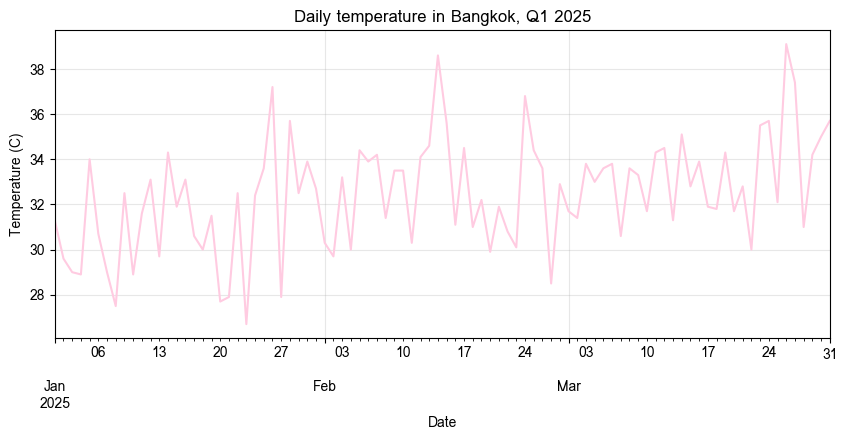

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color=PASTEL_COLORS[0], legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

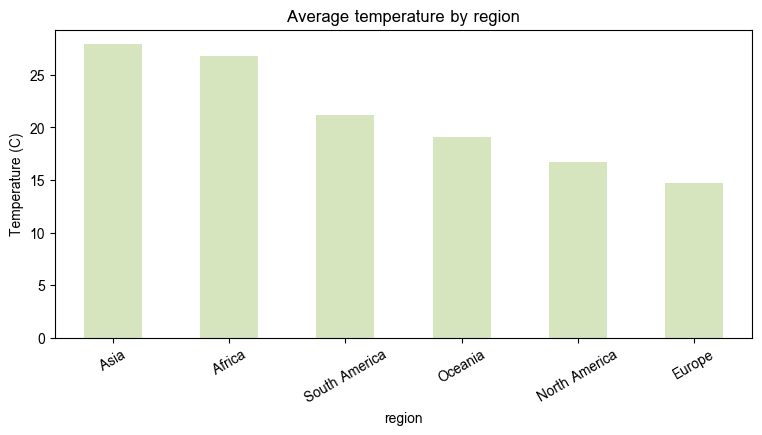

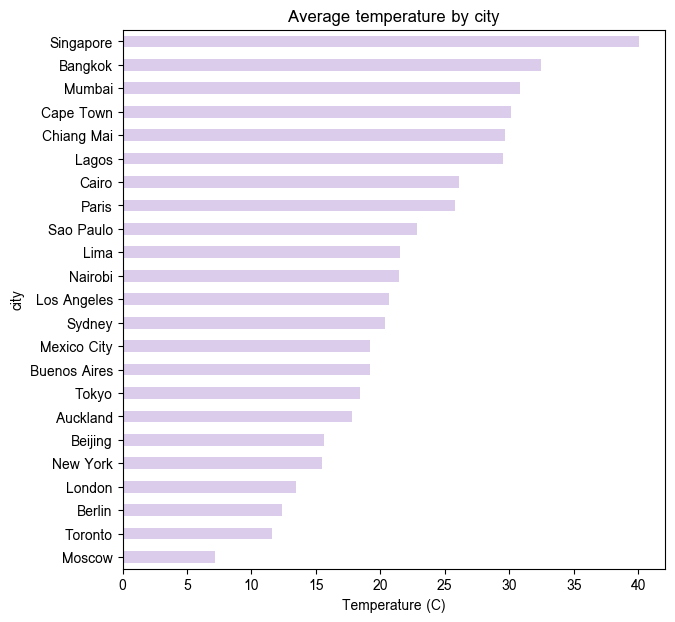

In [127]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color=PASTEL_COLORS[1])
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color=PASTEL_COLORS[4])
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

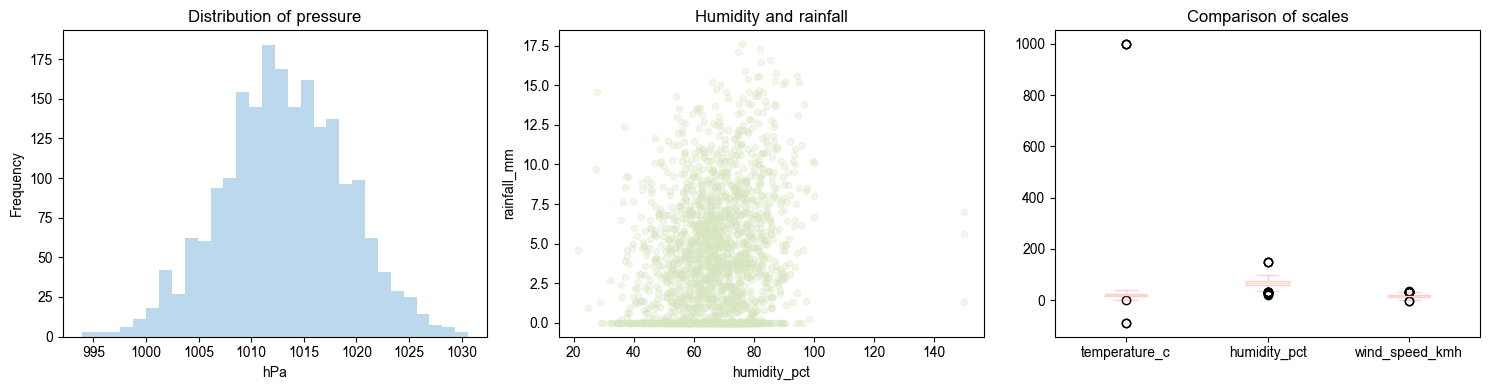

In [128]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color=PASTEL_COLORS[3])
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color=PASTEL_COLORS[1])
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

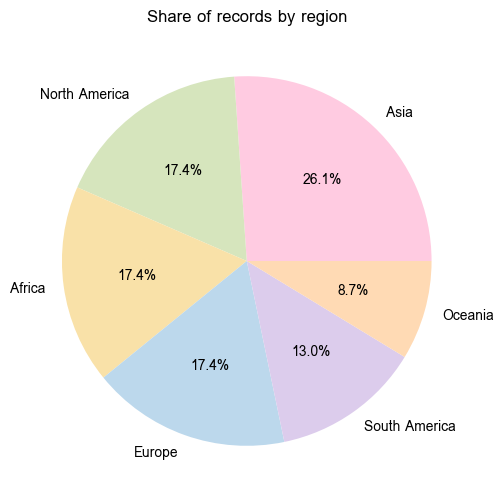

In [129]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="", colors=PASTEL_COLORS)
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

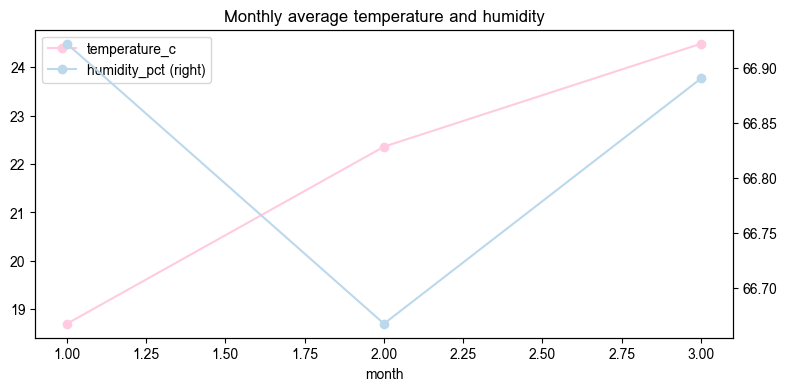

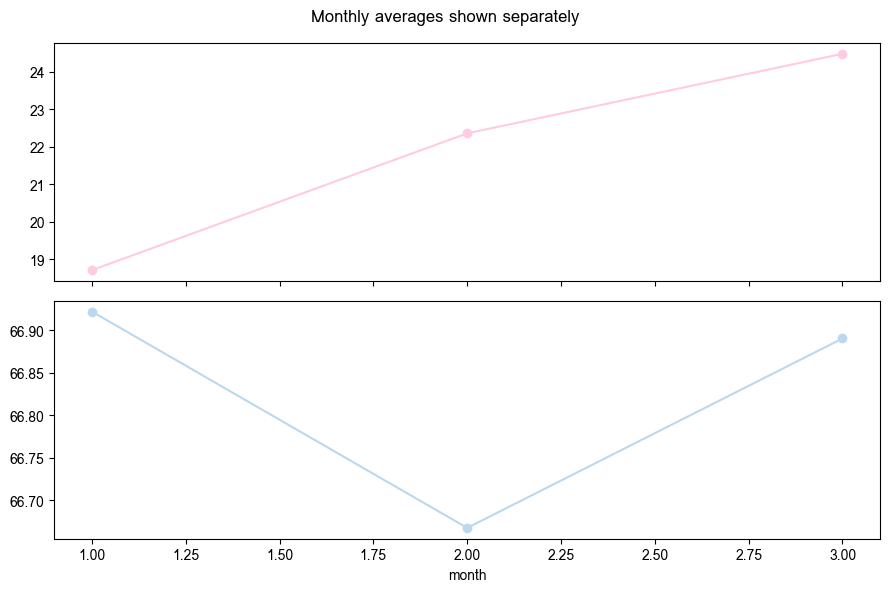

In [130]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct", color=[PASTEL_COLORS[0], PASTEL_COLORS[3]])
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False, color=[PASTEL_COLORS[0], PASTEL_COLORS[3]])
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

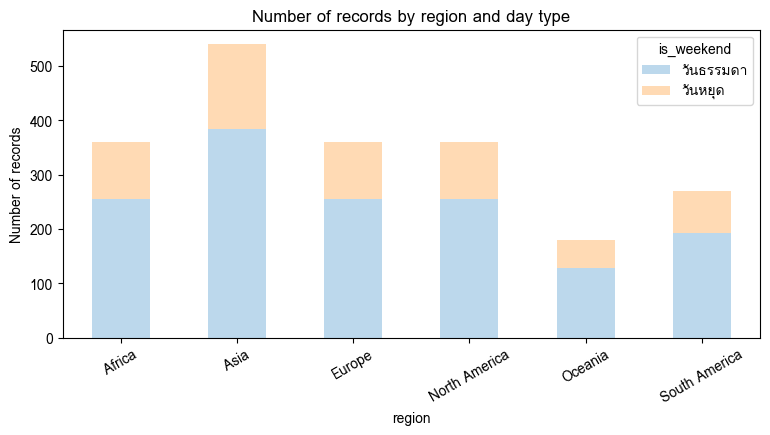

In [131]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=[PASTEL_COLORS[3], PASTEL_COLORS[5]])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

/tmp/ipykernel_3791/463372960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="region", y="temperature_c", ax=ax, palette=PASTEL_COLORS)


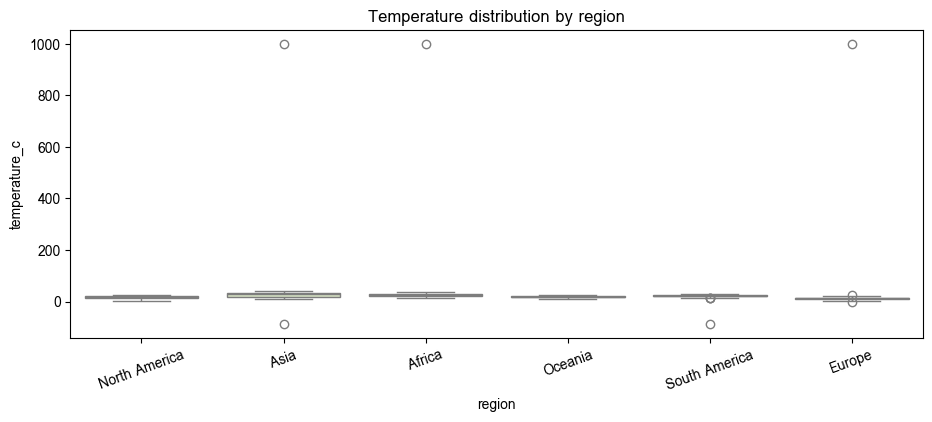

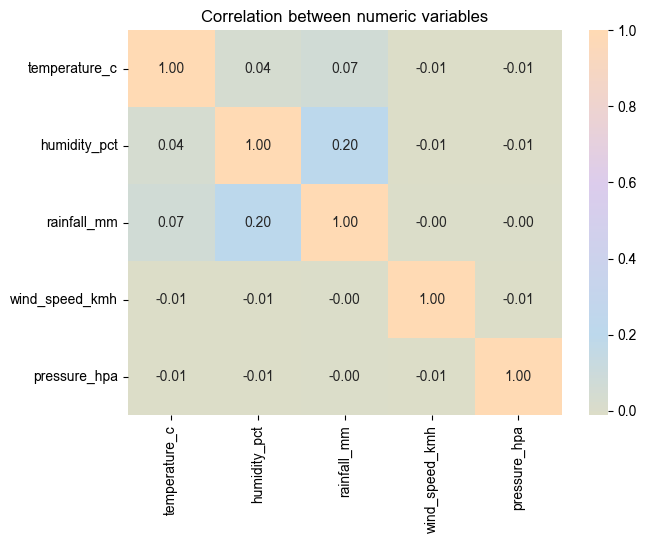

In [132]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax, palette=PASTEL_COLORS)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap=PASTEL_CMAP, center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

In [133]:
def plot_lines(ax):
    three = ["Bangkok", "Tokyo", "London"]
    (df[df["city"].isin(three)]
       .pivot(index="date", columns="city", values="temperature_valid")
       .plot(ax=ax, color=PASTEL_COLORS[:3]))
    ax.set_title("Daily temperature of three cities, Q1 2025")
    ax.set_xlabel("Date"); ax.set_ylabel("Temperature (C)")
    ax.legend(title="City"); ax.grid(alpha=0.3)

def plot_rain_barh(ax):
    df.groupby("city")["rainfall_mm"].sum().sort_values().plot(kind="barh", ax=ax, color=PASTEL_COLORS[3])
    ax.set_title("Total rainfall by city (sorted, highest on top)")
    ax.set_xlabel("Total rainfall (mm)"); ax.set_ylabel("City")

def plot_wind_hist(ax, bins):
    df.loc[df["wind_speed_kmh"] >= 0, "wind_speed_kmh"].plot(kind="hist", bins=bins, ax=ax, color=PASTEL_COLORS[1], edgecolor="white")
    ax.set_title(f"Wind speed histogram (bins={bins})")
    ax.set_xlabel("Wind speed (km/h)"); ax.set_ylabel("Frequency")

def plot_pop_scatter(ax):
    stats = (df.groupby("city").agg(avg_temp=("temperature_valid", "mean"))
               .join(city_info.set_index("city")["population_millions"]))
    stats.plot(kind="scatter", x="population_millions", y="avg_temp", ax=ax, color=PASTEL_COLORS[0])
    ax.set_title("City population vs average temperature")
    ax.set_xlabel("Population (millions)"); ax.set_ylabel("Average temperature (C)"); ax.grid(alpha=0.3)

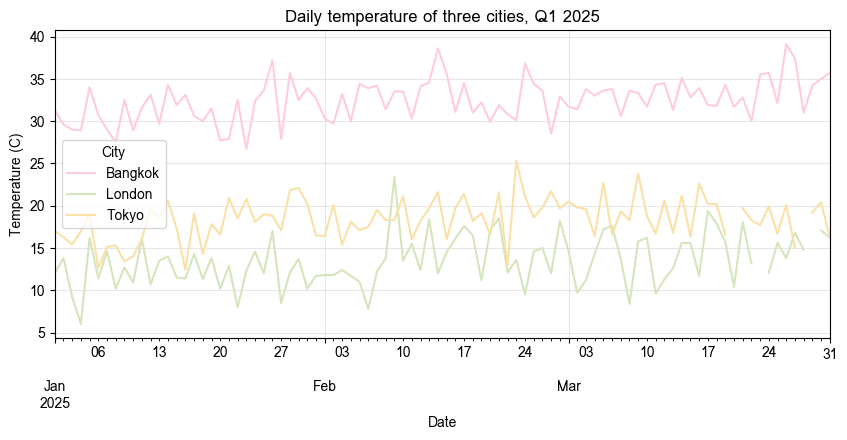

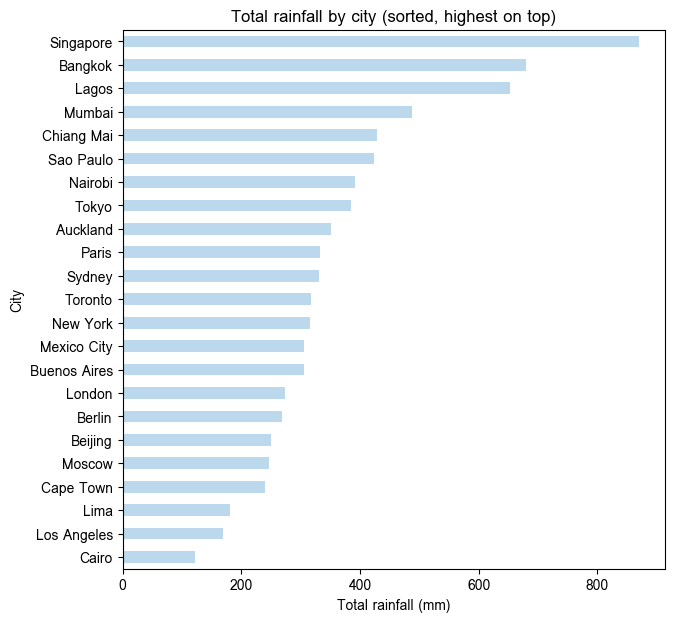

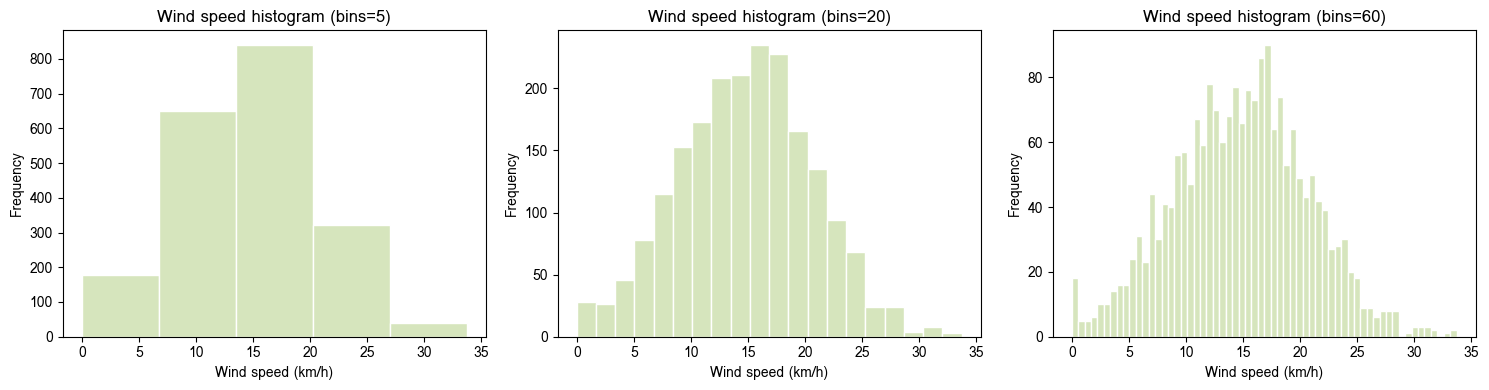

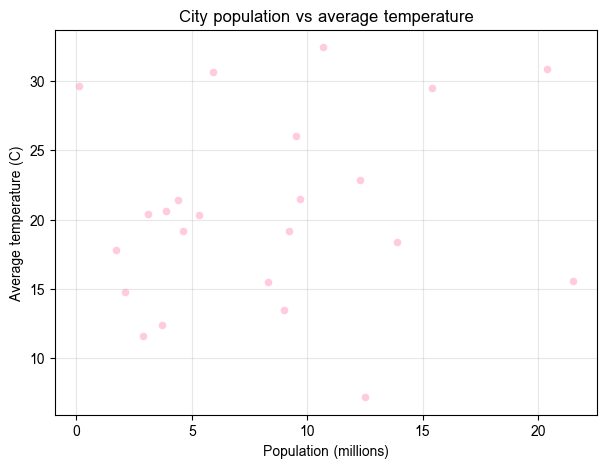

In [134]:
# คำตอบข้อ 17.1
# 1) กราฟเส้น
fig, ax = plt.subplots(figsize=(10, 4)); plot_lines(ax); plt.show()

# 2) กราฟแท่งแนวนอน
fig, ax = plt.subplots(figsize=(7, 7)); plot_rain_barh(ax); plt.show()

# 3) ฮิสโตแกรม ทดลอง bins สามค่า
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, b in zip(axes, [5, 20, 60]):
    plot_wind_hist(ax, b)
plt.tight_layout(); plt.show()

# 4) กราฟจุด
fig, ax = plt.subplots(figsize=(7, 5)); plot_pop_scatter(ax); plt.show()

**อธิบายผลของการเลือก `bins`**

- **`bins` น้อยเกินไป (เช่น 5):** แท่งกว้าง รายละเอียดหายไป เห็นเพียงรูปร่างหยาบ ๆ ซ่อนความเบ้และยอดที่แท้จริงของการกระจาย (under-fitting)
- **`bins` มากเกินไป (เช่น 60):** แท่งแคบมากจนแต่ละแท่งมีข้อมูลน้อย กราฟขรุขระเป็นฟันเลื่อย เห็นความผันผวนจากการสุ่มแทนรูปร่างจริง (over-fitting)
- **ค่าที่พอเหมาะ (ประมาณ 15-30 สำหรับข้อมูลราว 2,000 ค่า):** เห็นรูปร่างการกระจายชัดและเรียบพอ (อาจใช้กฎ Sturges หรือ √n เป็นจุดเริ่มต้น) ข้อมูลความเร็วลมมีลักษณะคล้ายระฆังคว่ำ จึงเห็นได้ชัดเมื่อใช้ bins ระดับกลาง

(กราฟนี้ตัดค่าความเร็วลมที่ติดลบซึ่งเป็นไปไม่ได้ออกก่อนวาด)

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

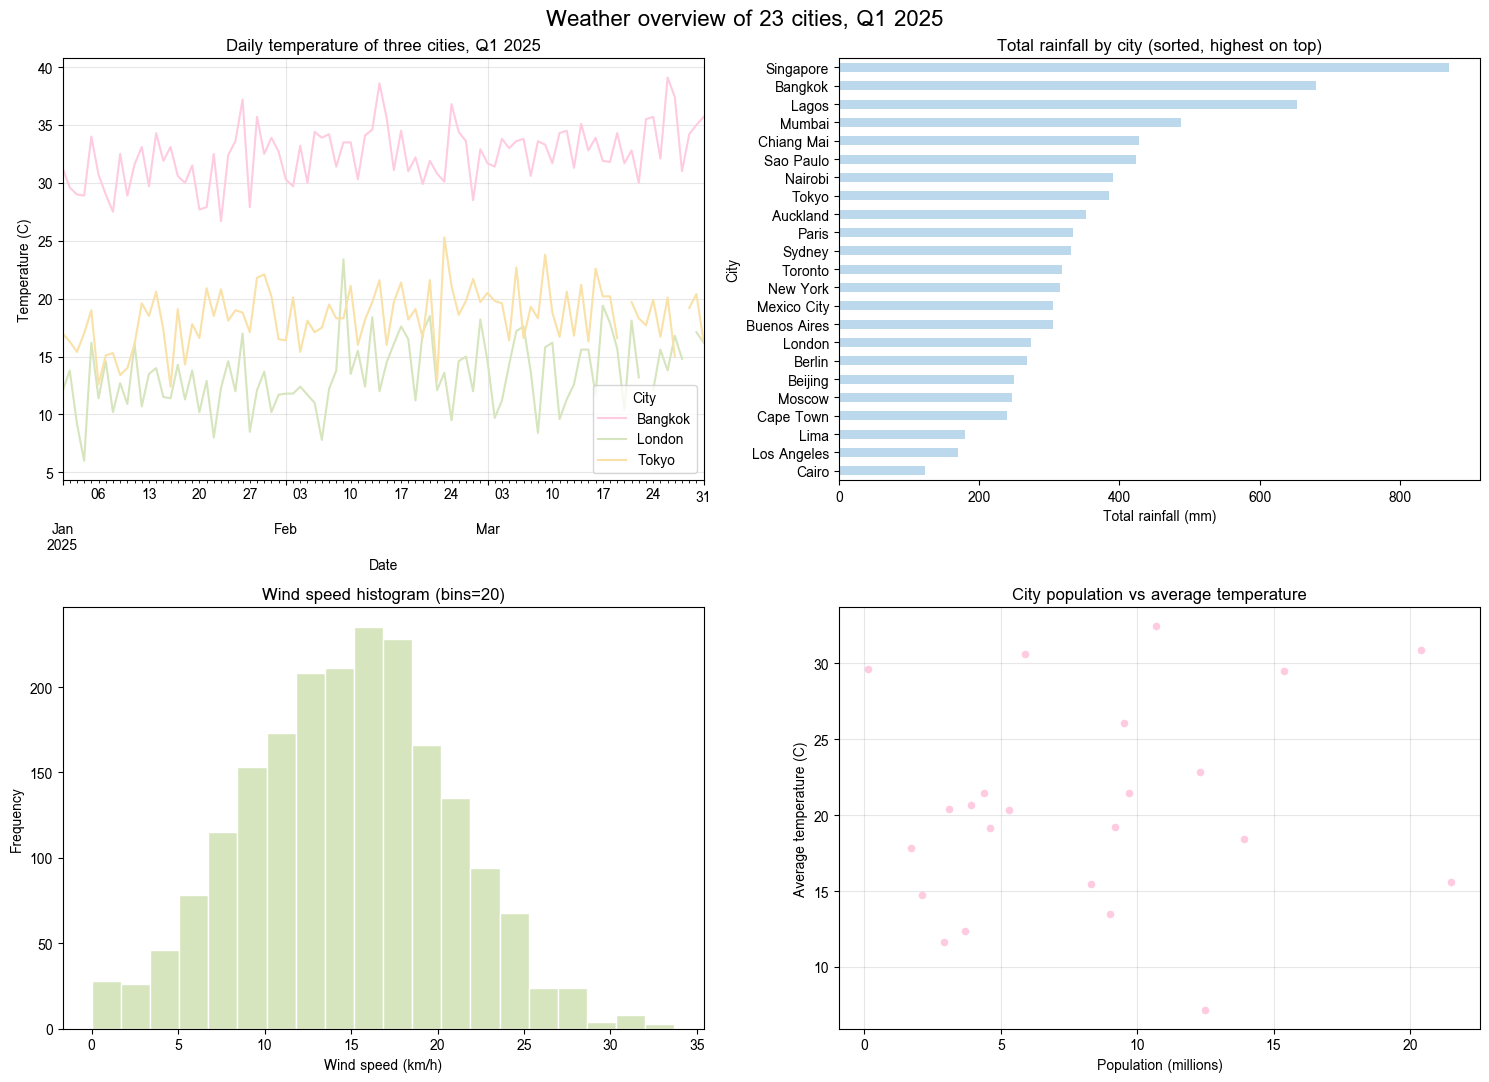

In [135]:
# คำตอบข้อ 17.2
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
plot_lines(axes[0, 0])
plot_rain_barh(axes[0, 1])
plot_wind_hist(axes[1, 0], bins=20)
plot_pop_scatter(axes[1, 1])
plt.suptitle("Weather overview of 23 cities, Q1 2025", fontsize=16)
plt.tight_layout()
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

rainfall_mm    no rain (0)  0-2.5  2.5-5  5-10  >10
region                                             
Africa                 101     44     85    88   31
Asia                    59     74    100   203   90
Europe                 106     67     89    73   15
North America           92     85     76    84   11
Oceania                 35     33     35    60    9
South America           76     52     62    52   21


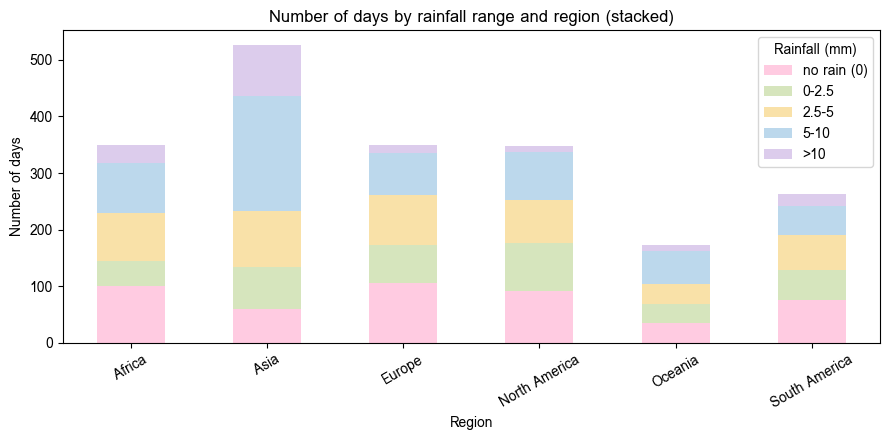

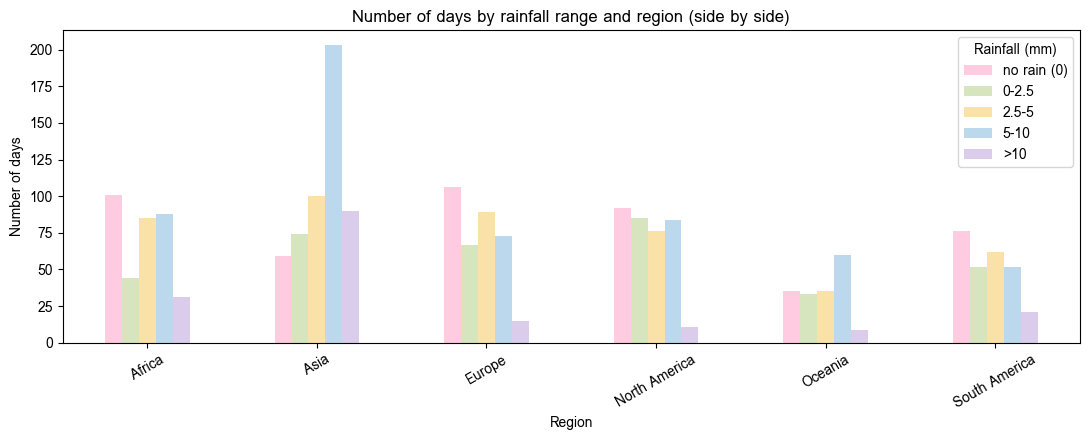

In [136]:
# คำตอบข้อ 17.3
rain_bin = pd.cut(df["rainfall_mm"], bins=[-np.inf, 0, 2.5, 5, 10, np.inf],
                  labels=["no rain (0)", "0-2.5", "2.5-5", "5-10", ">10"])
ct = pd.crosstab(df["region"], rain_bin)
print(ct)

fig, ax = plt.subplots(figsize=(9, 4.5))
ct.plot(kind="bar", stacked=True, ax=ax, color=PASTEL_COLORS[:len(ct.columns)])
ax.set_title("Number of days by rainfall range and region (stacked)")
ax.set_xlabel("Region"); ax.set_ylabel("Number of days"); ax.tick_params(axis="x", rotation=30)
ax.legend(title="Rainfall (mm)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
ct.plot(kind="bar", stacked=False, ax=ax, color=PASTEL_COLORS[:len(ct.columns)])
ax.set_title("Number of days by rainfall range and region (side by side)")
ax.set_xlabel("Region"); ax.set_ylabel("Number of days"); ax.tick_params(axis="x", rotation=30)
ax.legend(title="Rainfall (mm)"); plt.tight_layout(); plt.show()

- **กราฟแท่งซ้อน (`stacked=True`) เหมาะเมื่อ** ต้องการเห็น **ผลรวมทั้งหมดและส่วนประกอบ (องค์ประกอบต่อทั้งหมด)** ในแท่งเดียว เช่น ดูว่าแต่ละภูมิภาคมีจำนวนวันรวมเท่าใดและแบ่งเป็นช่วงฝนอย่างไร เหมาะเมื่อจำนวนหมวดย่อยไม่มาก และสนใจเปรียบเทียบผลรวมหรือเฉพาะส่วนล่างสุดของแท่ง
- **กราฟแท่งเรียงข้างกัน (`stacked=False`) เหมาะเมื่อ** ต้องการ **เปรียบเทียบค่าของแต่ละหมวดย่อยโดยตรงระหว่างกลุ่ม** เช่น เทียบจำนวนวันฝนหนักของทุกภูมิภาค เพราะทุกแท่งเริ่มจากเส้นฐานเดียวกัน อ่านความสูงเปรียบเทียบได้แม่นยำกว่า (ในกราฟแท่งซ้อน ส่วนที่อยู่ตรงกลางและด้านบนเริ่มจากเส้นฐานต่างกัน เปรียบเทียบยาก)

ในข้อมูลนี้ทุกภูมิภาคมีจำนวนวันรวมไม่เท่ากัน (ขึ้นกับจำนวนเมือง) การเทียบผลรวมจึงดูได้จากแท่งซ้อน แต่การเทียบจำนวนวันในช่วงใดช่วงหนึ่งข้ามภูมิภาคควรดูจากแท่งเรียงข้างกัน

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

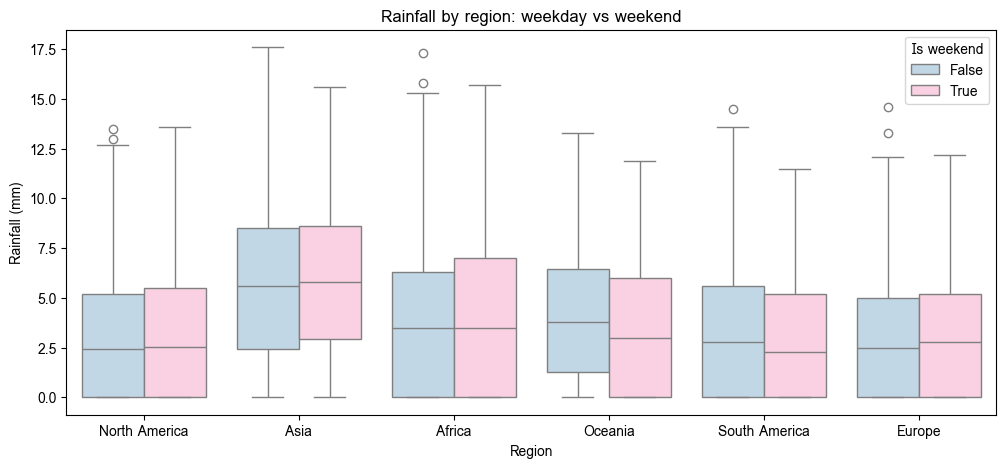

In [137]:
# คำตอบข้อ 17.4
df["is_weekend"] = df["date"].dt.dayofweek >= 5

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="region", y="rainfall_mm", hue="is_weekend", ax=ax, palette=[PASTEL_COLORS[3], PASTEL_COLORS[0]])
ax.set_title("Rainfall by region: weekday vs weekend")
ax.set_xlabel("Region"); ax.set_ylabel("Rainfall (mm)")
ax.legend(title="Is weekend"); plt.show()

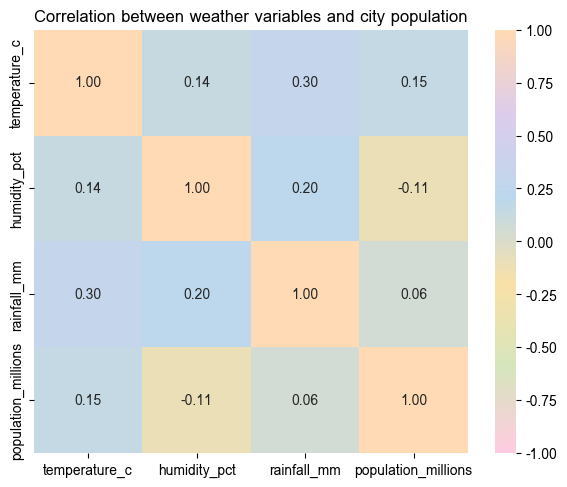

In [138]:
hm = (df.merge(city_info[["city", "population_millions"]], on="city", how="left", validate="many_to_one")
        .assign(temperature_c=lambda d: d["temperature_valid"],
                humidity_pct=lambda d: d["humidity_pct"].where(d["humidity_pct"].between(0, 100))))
corr = hm[["temperature_c", "humidity_pct", "rainfall_mm", "population_millions"]].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=PASTEL_CMAP, center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between weather variables and city population"); plt.show()

In [139]:
def strength(r):
    a = abs(r)
    return "แทบไม่มี" if a < 0.1 else "อ่อน" if a < 0.3 else "ปานกลาง" if a < 0.5 else "ค่อนข้างแรง" if a < 0.7 else "แรง"

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).unstack().dropna()     # ครึ่งบนของเมทริกซ์ (ไม่ซ้ำ ไม่รวมแนวทแยง)
heat_lines = "\n".join(f"- `{a}` กับ `{b}`: r = {r:+.2f} (ความสัมพันธ์{strength(r)}, {'ทิศทางเดียวกัน' if r > 0 else 'ทิศทางตรงข้าม'})"
                       for (a, b), r in pairs.items())

med = df.groupby(["region", "is_weekend"])["rainfall_mm"].median().unstack()
gap = (med[True] - med[False])
wet_region = df.groupby("region")["rainfall_mm"].median().idxmax()
display(Markdown(
    "**ตีความ boxplot:** ภูมิภาคที่ค่ามัธยฐานปริมาณฝนสูงที่สุดคือ **" + wet_region + "** "
    f"| ส่วนต่างค่ามัธยฐานฝน (วันหยุด - วันธรรมดา) อยู่ระหว่าง {gap.min():+.2f} ถึง {gap.max():+.2f} มม. "
    f"(ต่างกันมากที่สุดที่ {gap.abs().idxmax()}) ซึ่งเล็กเมื่อเทียบกับความต่างระหว่างภูมิภาค "
    "และสภาพฝนไม่ได้ขึ้นกับวันในสัปดาห์โดยธรรมชาติ ความต่างเล็กน้อยจึงน่าจะเกิดจากความผันผวนแบบสุ่ม\n\n"
    "**ตีความ heatmap:**\n" + heat_lines +
    "\n\n*ข้อควรระวัง:* `population_millions` เป็นค่าระดับเมือง (มีเพียง 23 ค่า ซ้ำในทุกวันของเมืองเดียวกัน) "
    "ค่า r จึงไม่ได้มาจากข้อมูลอิสระ 2,000 จุด และสหสัมพันธ์ไม่ได้แปลว่าเป็นเหตุและผล"))

**ตีความ boxplot:** ภูมิภาคที่ค่ามัธยฐานปริมาณฝนสูงที่สุดคือ **Asia** | ส่วนต่างค่ามัธยฐานฝน (วันหยุด - วันธรรมดา) อยู่ระหว่าง -0.80 ถึง +0.30 มม. (ต่างกันมากที่สุดที่ Oceania) ซึ่งเล็กเมื่อเทียบกับความต่างระหว่างภูมิภาค และสภาพฝนไม่ได้ขึ้นกับวันในสัปดาห์โดยธรรมชาติ ความต่างเล็กน้อยจึงน่าจะเกิดจากความผันผวนแบบสุ่ม

**ตีความ heatmap:**
- `humidity_pct` กับ `temperature_c`: r = +0.14 (ความสัมพันธ์อ่อน, ทิศทางเดียวกัน)
- `rainfall_mm` กับ `temperature_c`: r = +0.30 (ความสัมพันธ์อ่อน, ทิศทางเดียวกัน)
- `rainfall_mm` กับ `humidity_pct`: r = +0.20 (ความสัมพันธ์อ่อน, ทิศทางเดียวกัน)
- `population_millions` กับ `temperature_c`: r = +0.15 (ความสัมพันธ์อ่อน, ทิศทางเดียวกัน)
- `population_millions` กับ `humidity_pct`: r = -0.11 (ความสัมพันธ์อ่อน, ทิศทางตรงข้าม)
- `population_millions` กับ `rainfall_mm`: r = +0.06 (ความสัมพันธ์แทบไม่มี, ทิศทางเดียวกัน)

*ข้อควรระวัง:* `population_millions` เป็นค่าระดับเมือง (มีเพียง 23 ค่า ซ้ำในทุกวันของเมืองเดียวกัน) ค่า r จึงไม่ได้มาจากข้อมูลอิสระ 2,000 จุด และสหสัมพันธ์ไม่ได้แปลว่าเป็นเหตุและผล

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

In [140]:
# เตรียมตารางรวมข้อมูลจาก 3 แหล่งและทำความสะอาดแล้ว (ใช้กับข้อ 18.1 - 18.4)
base_cols = ["date", "month", "city", "country", "region", "temperature_c", "humidity_pct",
             "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]       # df ขจัดข้อมูลซ้ำแล้ว (ข้อ 9) และ normalize country แล้ว (ข้อ 4.3)
ov_ci = [c for c in city_info.columns if c in base_cols and c != "city"]                   # คอลัมน์ชื่อซ้ำกับตารางหลัก ตัดฝั่งขวาทิ้ง
clean = df[base_cols].merge(city_info.drop(columns=ov_ci), on="city", how="left", validate="many_to_one")
ov_ri = [c for c in region_info.columns if c in clean.columns and c != "region"]
clean = (clean.merge(region_info.drop(columns=ov_ri), on="region", how="left", validate="many_to_one")
              .assign(temperature_c=lambda d: d["temperature_c"].where(d["temperature_c"].between(-60, 60)),     # ค่าผิดปกติ -> ว่าง
                      humidity_pct=lambda d: d["humidity_pct"].where(d["humidity_pct"].between(0, 100)),
                      wind_speed_kmh=lambda d: d["wind_speed_kmh"].where(d["wind_speed_kmh"] >= 0)))

print("ตารางรวมที่ทำความสะอาดแล้ว:", clean.shape, "| ไม่มีแถวซ้ำ (city, date):", not clean.duplicated(["city", "date"]).any(),
      "| จำนวนประเทศ:", clean["country"].nunique())
print("ค่าว่างต่อคอลัมน์ (ไม่ได้เติมค่า สถิติทุกตัวข้ามค่าว่างโดยอัตโนมัติ):")
print(clean[["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh"]].isna().sum().to_string())

ตารางรวมที่ทำความสะอาดแล้ว: (2070, 14) | ไม่มีแถวซ้ำ (city, date): True | จำนวนประเทศ: 21
ค่าว่างต่อคอลัมน์ (ไม่ได้เติมค่า สถิติทุกตัวข้ามค่าว่างโดยอัตโนมัติ):
temperature_c     25
humidity_pct      85
rainfall_mm       62
wind_speed_kmh    43


**วิธีทำความสะอาดที่ใช้ในข้อ 18**

1. ใช้ตารางที่ **ขจัดข้อมูลซ้ำ** (ข้อ 8-9) และ **normalize ชื่อประเทศ** (ข้อ 4.3) แล้ว
2. รวมกับ `city_info` (ตามเมือง) และ `region_info` (ตามภูมิภาค) ด้วย `validate="many_to_one"` และตัดคอลัมน์ชื่อซ้ำออก
3. **ค่าผิดปกติ** (อุณหภูมินอกช่วง -60..60, ความชื้นนอกช่วง 0..100, ความเร็วลมติดลบ) **แทนด้วยค่าว่าง** ด้วย `where` ไม่ลบแถว
4. **ค่าว่างไม่เติมค่า** ฟังก์ชันสถิติข้ามค่าว่างโดยอัตโนมัติ ส่วนการนับสัดส่วนใช้จำนวนวันที่มีข้อมูลจริงเป็นตัวหาร

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [141]:
# คำตอบข้อ 18.1
reg_std = clean.groupby("region")["temperature_c"].std().sort_values(ascending=False).rename("std_temp")
print("ส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวันรวมทุกเมือง (องศา) จำแนกตามภูมิภาค")
print(reg_std.round(2).to_string())

top_region = reg_std.index[0]
sub = clean[clean["region"] == top_region]
city_std = (sub.groupby("city")["temperature_c"].agg(mean_temp="mean", std_temp="std", n_days="count")
               .sort_values("std_temp", ascending=False))
print(f"\nส่วนประกอบรายเมืองของภูมิภาค {top_region}")
print(city_std.round(2))

# แยกความแปรปรวนรวม = ภายในเมือง + ระหว่างเมือง (SS รวม = SS ภายใน + SS ระหว่าง)
ss_total = (sub["temperature_c"].count() - 1) * sub["temperature_c"].var()
ss_within = ((city_std["n_days"] - 1) * city_std["std_temp"] ** 2).sum()
between_share = 1 - ss_within / ss_total
others = city_std["std_temp"].iloc[1:]
display(Markdown(
    f"**สรุป:** ภูมิภาคที่แปรปรวนที่สุดในไตรมาสแรกคือ **{top_region}** (std = {reg_std.iloc[0]:.2f} องศา) "
    f"ความแปรปรวนนี้ **{'ไม่ได้เกิดจากทุกเมืองเท่ากัน' if city_std['std_temp'].max() > 1.5 * others.median() else 'มาจากทุกเมืองในระดับใกล้เคียงกัน'}** "
    f"เมืองที่ผันผวนรายวันมากที่สุดคือ {city_std.index[0]} (std = {city_std['std_temp'].iloc[0]:.2f}) เทียบกับค่ากลางของเมืองอื่น {others.median():.2f} "
    f"และ **{between_share*100:.0f}%** ของความแปรปรวนรวมมาจากการที่เมืองต่าง ๆ มีระดับอุณหภูมิเฉลี่ยต่างกัน "
    f"(ที่เหลือคือความผันผวนรายวันภายในเมือง) | วิธีจัดการ: ค่าผิดปกติแทนด้วยค่าว่าง ไม่เติมค่า"))

ส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวันรวมทุกเมือง (องศา) จำแนกตามภูมิภาค
region
Asia             7.16
Africa           4.88
North America    4.52
Europe           4.07
Oceania          3.08
South America    3.06

ส่วนประกอบรายเมืองของภูมิภาค Asia
            mean_temp  std_temp  n_days
city                                   
Beijing         15.60      2.87      89
Chiang Mai      29.65      2.86      90
Singapore       30.64      2.71      88
Mumbai          30.87      2.54      90
Tokyo           18.41      2.52      88
Bangkok         32.44      2.49      90


**สรุป:** ภูมิภาคที่แปรปรวนที่สุดในไตรมาสแรกคือ **Asia** (std = 7.16 องศา) ความแปรปรวนนี้ **มาจากทุกเมืองในระดับใกล้เคียงกัน** เมืองที่ผันผวนรายวันมากที่สุดคือ Beijing (std = 2.87) เทียบกับค่ากลางของเมืองอื่น 2.54 และ **86%** ของความแปรปรวนรวมมาจากการที่เมืองต่าง ๆ มีระดับอุณหภูมิเฉลี่ยต่างกัน (ที่เหลือคือความผันผวนรายวันภายในเมือง) | วิธีจัดการ: ค่าผิดปกติแทนด้วยค่าว่าง ไม่เติมค่า

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [142]:
# คำตอบข้อ 18.2
hv = (clean.assign(heavy=clean["rainfall_mm"] > 10, valid=clean["rainfall_mm"].notna())
           .groupby("city").agg(n_heavy=("heavy", "sum"), n_valid_days=("valid", "sum")))
hv["pct_heavy"] = (hv["n_heavy"] / hv["n_valid_days"] * 100).round(2)
hv["rank_by_pct"] = hv["pct_heavy"].rank(ascending=False, method="min").astype(int)
hv["rank_by_count"] = hv["n_heavy"].rank(ascending=False, method="min").astype(int)

print("เมืองที่ติด 5 อันดับแรกตามสัดส่วน หรือ ตามจำนวนวัน (เรียงตามสัดส่วน)")
print(hv[(hv["rank_by_pct"] <= 5) | (hv["rank_by_count"] <= 5)].sort_values("rank_by_pct"))

top_pct = hv.nsmallest(5, "rank_by_pct").index.tolist()
top_cnt = hv.nsmallest(5, "rank_by_count").index.tolist()
display(Markdown(
    f"**สรุป:** 5 อันดับแรกตามสัดส่วน = {top_pct} | ตามจำนวนวัน = {top_cnt} -> "
    + ("รายชื่อเหมือนกัน" if set(top_pct) == set(top_cnt) else "รายชื่อต่างกัน")
    + f" (จำนวนวันที่มีข้อมูลฝนของแต่ละเมืองต่างกัน {int(hv['n_valid_days'].min())}-{int(hv['n_valid_days'].max())} วัน) "
    "สาเหตุที่อาจให้ผลต่างกัน: ค่าว่างของ `rainfall_mm` กระจายไม่เท่ากันระหว่างเมือง เมืองที่ข้อมูลครบกว่ามีโอกาสนับวันฝนหนักได้มากกว่า "
    "โดยไม่ได้แปลว่าฝนหนักบ่อยกว่า ส่วนสัดส่วนปรับด้วยจำนวนวันที่มีข้อมูลจริงจึงเปรียบเทียบได้เป็นธรรมกว่า "
    "| เกณฑ์ฝนหนัก = มากกว่า 10 มม./วัน ค่าว่างไม่ถูกนับเป็นวันฝนหนักและไม่ถูกนับในตัวหาร"))

เมืองที่ติด 5 อันดับแรกตามสัดส่วน หรือ ตามจำนวนวัน (เรียงตามสัดส่วน)
              n_heavy  n_valid_days  pct_heavy  rank_by_pct  rank_by_count
city                                                                      
Singapore          44            90      48.89            1              1
Bangkok            23            87      26.44            2              2
Lagos              22            88      25.00            3              3
Sao Paulo          11            88      12.50            4              4
Chiang Mai          9            85      10.59            5              5
Buenos Aires        9            88      10.23            6              5


**สรุป:** 5 อันดับแรกตามสัดส่วน = ['Singapore', 'Bangkok', 'Lagos', 'Sao Paulo', 'Chiang Mai'] | ตามจำนวนวัน = ['Singapore', 'Bangkok', 'Lagos', 'Sao Paulo', 'Buenos Aires'] -> รายชื่อต่างกัน (จำนวนวันที่มีข้อมูลฝนของแต่ละเมืองต่างกัน 85-90 วัน) สาเหตุที่อาจให้ผลต่างกัน: ค่าว่างของ `rainfall_mm` กระจายไม่เท่ากันระหว่างเมือง เมืองที่ข้อมูลครบกว่ามีโอกาสนับวันฝนหนักได้มากกว่า โดยไม่ได้แปลว่าฝนหนักบ่อยกว่า ส่วนสัดส่วนปรับด้วยจำนวนวันที่มีข้อมูลจริงจึงเปรียบเทียบได้เป็นธรรมกว่า | เกณฑ์ฝนหนัก = มากกว่า 10 มม./วัน ค่าว่างไม่ถูกนับเป็นวันฝนหนักและไม่ถูกนับในตัวหาร

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [143]:
# คำตอบข้อ 18.3
cs = (clean.groupby("city").agg(avg_temp=("temperature_c", "mean"), avg_rain=("rainfall_mm", "mean"),
                                population_millions=("population_millions", "first")))
targets = ["avg_temp", "avg_rain"]
res = pd.DataFrame({
    "Pearson (ระดับเมือง n=23)": cs[targets].corrwith(cs["population_millions"]),
    "Spearman (ระดับเมือง n=23)": cs[targets].corrwith(cs["population_millions"], method="spearman"),
    "Pearson (ระดับแถวข้อมูล)": clean[["temperature_c", "rainfall_mm"]].corrwith(clean["population_millions"]).set_axis(targets),
}).rename(index={"avg_temp": "อุณหภูมิ", "avg_rain": "ปริมาณฝนเฉลี่ยต่อวัน"})
print("สหสัมพันธ์ของจำนวนประชากร (ล้านคน) กับอุณหภูมิ/ปริมาณฝน")
print(res.round(3))

def strength(r):
    a = abs(r)
    return "แทบไม่มี" if a < 0.1 else "อ่อน" if a < 0.3 else "ปานกลาง" if a < 0.5 else "ค่อนข้างแรง" if a < 0.7 else "แรง"
rt, rr = res.iloc[0, 0], res.iloc[1, 0]
display(Markdown(
    f"**สรุป:** ระดับเมือง ประชากรกับอุณหภูมิเฉลี่ย r = {rt:+.2f} (สัมพันธ์{strength(rt)}) และกับปริมาณฝน r = {rr:+.2f} (สัมพันธ์{strength(rr)}) "
    "| วิธีจัดการ: ค่าผิดปกติแทนด้วยค่าว่าง ใช้ค่าเฉลี่ยรายเมืองเพื่อไม่ให้เมืองที่ข้อมูลมากกว่ามีน้ำหนักเกิน\n\n"
    "**ข้อควรระวังในการตีความ:** (1) มีเพียง 23 เมือง ตัวอย่างน้อย r ผันผวนง่ายและแปรผันตามเมืองใหญ่เพียงไม่กี่เมือง "
    "(2) สหสัมพันธ์ไม่ใช่เหตุและผล ประชากรอาจสัมพันธ์กับตำแหน่งที่ตั้ง (ละติจูด/ชายฝั่ง/ภูมิภาค) ซึ่งเป็นตัวแปรแอบแฝงที่กำหนดอากาศจริง "
    "(3) ค่าประชากรเป็นระดับเมือง ซ้ำทุกวันของเมืองเดียวกัน ค่า r ระดับแถวข้อมูลจึงไม่ได้มาจากข้อมูลอิสระ 2,000 จุด "
    "(4) Pearson วัดเฉพาะความสัมพันธ์เชิงเส้นและไวต่อเมืองสุดโต่ง จึงเทียบกับ Spearman ประกอบ"))

สหสัมพันธ์ของจำนวนประชากร (ล้านคน) กับอุณหภูมิ/ปริมาณฝน
                      Pearson (ระดับเมือง n=23)  Spearman (ระดับเมือง n=23)  \
อุณหภูมิ                                  0.159                       0.230   
ปริมาณฝนเฉลี่ยต่อวัน                      0.123                       0.057   

                      Pearson (ระดับแถวข้อมูล)  
อุณหภูมิ                                 0.146  
ปริมาณฝนเฉลี่ยต่อวัน                     0.061  


**สรุป:** ระดับเมือง ประชากรกับอุณหภูมิเฉลี่ย r = +0.16 (สัมพันธ์อ่อน) และกับปริมาณฝน r = +0.12 (สัมพันธ์อ่อน) | วิธีจัดการ: ค่าผิดปกติแทนด้วยค่าว่าง ใช้ค่าเฉลี่ยรายเมืองเพื่อไม่ให้เมืองที่ข้อมูลมากกว่ามีน้ำหนักเกิน

**ข้อควรระวังในการตีความ:** (1) มีเพียง 23 เมือง ตัวอย่างน้อย r ผันผวนง่ายและแปรผันตามเมืองใหญ่เพียงไม่กี่เมือง (2) สหสัมพันธ์ไม่ใช่เหตุและผล ประชากรอาจสัมพันธ์กับตำแหน่งที่ตั้ง (ละติจูด/ชายฝั่ง/ภูมิภาค) ซึ่งเป็นตัวแปรแอบแฝงที่กำหนดอากาศจริง (3) ค่าประชากรเป็นระดับเมือง ซ้ำทุกวันของเมืองเดียวกัน ค่า r ระดับแถวข้อมูลจึงไม่ได้มาจากข้อมูลอิสระ 2,000 จุด (4) Pearson วัดเฉพาะความสัมพันธ์เชิงเส้นและไวต่อเมืองสุดโต่ง จึงเทียบกับ Spearman ประกอบ

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [144]:
# คำตอบข้อ 18.4
# เกณฑ์ตัดสิน: "วันที่ไม่เหมาะกับการเดินทาง" = วันที่เข้าเงื่อนไขอย่างน้อยหนึ่งข้อ
#   ฝนหนัก (> 10 มม.) | ร้อนจัด (> 35 องศา) | หนาวจัด (< 0 องศา) | ลมแรง (> 25 กม./ชม.)
# แล้วคำนวณ "ร้อยละของวันที่ไม่เหมาะ" ของแต่ละภูมิภาคในแต่ละเดือน เดือนที่ร้อยละสูงสุดคือเดือนที่ควรหลีกเลี่ยง
bad_day = ((clean["rainfall_mm"] > 10) | (clean["temperature_c"] > 35) |
           (clean["temperature_c"] < 0) | (clean["wind_speed_kmh"] > 25)).astype(int)
risk = (clean.assign(bad_day=bad_day)
             .pivot_table(index="region", columns="month", values="bad_day", aggfunc="mean") * 100).round(1)
risk["เดือนที่ควรหลีกเลี่ยง"] = risk.idxmax(axis=1)
print("ร้อยละของวันที่ไม่เหมาะกับการเดินทาง จำแนกตามภูมิภาคและเดือน (เดือน 1-3 = ม.ค.-มี.ค. 2025)")
print(risk)

worst = risk.drop(columns="เดือนที่ควรหลีกเลี่ยง").max(axis=1)
display(Markdown("**สรุป:** " + " | ".join(f"{r}: เดือน {int(risk.loc[r, 'เดือนที่ควรหลีกเลี่ยง'])} ({worst[r]:.1f}% ของวัน)" for r in risk.index)))

ร้อยละของวันที่ไม่เหมาะกับการเดินทาง จำแนกตามภูมิภาคและเดือน (เดือน 1-3 = ม.ค.-มี.ค. 2025)
month             1     2     3  เดือนที่ควรหลีกเลี่ยง
region                                                
Africa         12.9   9.8  10.5                      1
Asia           20.4  25.0  22.0                      2
Europe          6.5   8.0   8.9                      3
North America   5.6   6.2   7.3                      3
Oceania         6.5   5.4   9.7                      3
South America  11.8   9.5  11.8                      1


**สรุป:** Africa: เดือน 1 (12.9% ของวัน) | Asia: เดือน 2 (25.0% ของวัน) | Europe: เดือน 3 (8.9% ของวัน) | North America: เดือน 3 (7.3% ของวัน) | Oceania: เดือน 3 (9.7% ของวัน) | South America: เดือน 1 (11.8% ของวัน)

**เหตุผลของเกณฑ์ที่เลือก**

- ใช้ **ร้อยละของวันที่มีสภาพอากาศไม่เหมาะ** เพราะเป็นตัวชี้วัดที่ตีความตรง ๆ ว่า "ใน 10 วัน มีกี่วันที่การเดินทางเสี่ยงหรือไม่สบาย" และเปรียบเทียบข้ามภูมิภาค/เดือนได้แม้จำนวนเมืองและจำนวนวันต่างกัน
- เงื่อนไข **ฝนหนัก > 10 มม.** ตรงกับเกณฑ์ที่ใช้นิยามวันฝนหนักในโจทย์ก่อนหน้า, **ลมแรง > 25 กม./ชม.** ตรงกับเกณฑ์ลมแรงในตัวอย่างข้อ 16, **ร้อนจัด > 35 องศา** และ **หนาวจัด < 0 องศา** เป็นระดับที่เริ่มเสี่ยงต่อสุขภาพและการเดินทางทั่วไป
- ใช้ "อย่างน้อยหนึ่งเงื่อนไข" (OR) เพราะปัจจัยใดปัจจัยหนึ่งเพียงอย่างเดียวก็ทำให้ทริปแย่ได้ ไม่ต้องรวมคะแนนหลายปัจจัยที่หน่วยต่างกัน
- ค่าว่างและค่าผิดปกติ (ถูกแทนด้วยค่าว่างแล้ว) ไม่ถูกนับเป็นวันที่ไม่เหมาะ จึงอาจประเมินต่ำกว่าจริงเล็กน้อยในเดือนที่ข้อมูลหายมาก
- ข้อมูลมีเพียง 3 เดือน (ม.ค.-มี.ค.) ข้อสรุปจึงใช้เทียบเฉพาะในช่วงนี้ ไม่ใช่ตลอดทั้งปี

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️